In [1]:
# Install required packages
!pip install -q pandas numpy scikit-learn xgboost shap matplotlib joblib


[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [6]:
%pip install --upgrade pip

   ---------------------------------------- 0.0/1.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.8 MB ? eta -:--:--
   ----------- ---------------------------- 0.5/1.8 MB 19.8 MB/s eta 0:00:01
   ---------------------------- ----------- 1.3/1.8 MB 5.6 MB/s eta 0:00:01
   ---------------------------------------- 1.8/1.8 MB 3.6 MB/s  0:00:00
  Attempting uninstall: pip
    Found existing installation: pip 26.0.1
    Uninstalling pip-26.0.1:
      Successfully uninstalled pip-26.0.1
Note: you may need to restart the kernel to use updated packages.


In [1]:
# Import libraries and set reproducibility

import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path

# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Setup completed successfully.")
print("Random state:", RANDOM_STATE)


Setup completed successfully.
Random state: 42


In [ ]:
#==========================================================
# Step 1 — Project Setup + Load and Validate Dataset
#==========================================================

from pathlib import Path
import os

PROJECT_DIR = Path.home() / "Pictures" / "Own Research"

DATA_PATH = PROJECT_DIR / "creditcard.csv"
FIGURES_DIR = PROJECT_DIR / "figures"
RESULTS_DIR = PROJECT_DIR / "results"
MODELS_DIR = PROJECT_DIR / "models"

FIGURES_DIR.mkdir(exist_ok=True)
RESULTS_DIR.mkdir(exist_ok=True)
MODELS_DIR.mkdir(exist_ok=True)

print("Project folder:", PROJECT_DIR)
print("Dataset path:", DATA_PATH)
print("Dataset exists:", DATA_PATH.exists())

Project folder: C:\Users\eliya\Pictures\Own Research
Dataset path: C:\Users\eliya\Pictures\Own Research\creditcard.csv
Dataset exists: True


In [3]:
import pandas as pd

df = pd.read_csv(DATA_PATH)

print("Dataset loaded successfully.")
print("Dataset shape:", df.shape)

Dataset loaded successfully.
Dataset shape: (284807, 31)


In [4]:
# Check column names
print("Number of columns:", len(df.columns))
print(df.columns.tolist())

Number of columns: 31
['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']


In [5]:
# Check dataset structure
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [6]:
# Check missing values
missing_values = df.isnull().sum()

print("Total missing values:", missing_values.sum())

print("\nColumns with missing values:")
print(missing_values[missing_values > 0])

Total missing values: 0

Columns with missing values:
Series([], dtype: int64)


In [7]:
# Check duplicate rows
duplicate_count = df.duplicated().sum()
duplicate_percentage = (duplicate_count / len(df)) * 100

print("Number of duplicated rows:", duplicate_count)
print(f"Percentage of duplicated rows: {duplicate_percentage:.4f}%")

Number of duplicated rows: 1081
Percentage of duplicated rows: 0.3796%


In [8]:
# Check target classes
print("Unique target values:")
print(sorted(df["Class"].unique()))

print("\nClass counts:")
print(df["Class"].value_counts().sort_index())

Unique target values:
[np.int64(0), np.int64(1)]

Class counts:
Class
0    284315
1       492
Name: count, dtype: int64


In [9]:
# Class percentages and imbalance ratio
class_counts = df["Class"].value_counts().sort_index()

class_percentages = (
    df["Class"]
    .value_counts(normalize=True)
    .sort_index()
    * 100
)

class_summary = pd.DataFrame({
    "Count": class_counts,
    "Percentage": class_percentages
})

class_summary.index = ["Legitimate", "Fraud"]

print(class_summary)

normal_count = (df["Class"] == 0).sum()
fraud_count = (df["Class"] == 1).sum()

imbalance_ratio = normal_count / fraud_count

print("\nNormal transactions:", normal_count)
print("Fraudulent transactions:", fraud_count)
print(f"Imbalance ratio: approximately {imbalance_ratio:.2f}:1")

             Count  Percentage
Legitimate  284315   99.827251
Fraud          492    0.172749

Normal transactions: 284315
Fraudulent transactions: 492
Imbalance ratio: approximately 577.88:1


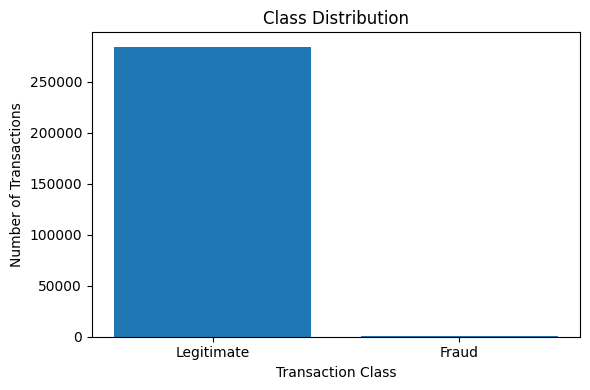

In [ ]:
##==========================================================
# Exploratory Data Analysis
##==========================================================

# Class Distribution Plot

class_counts = df["Class"].value_counts().sort_index()

plt.figure(figsize=(6, 4))
plt.bar(["Legitimate", "Fraud"], class_counts.values)

plt.title("Class Distribution")
plt.xlabel("Transaction Class")
plt.ylabel("Number of Transactions")

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "class_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()



In [ ]:
# Transaction amount summary

print("Overall Amount Statistics:")
print(df["Amount"].describe())

print("\nAmount Statistics by Class:")
print(
    df.groupby("Class")["Amount"]
    .describe()
)

# This helps us compare fraud and legitimate transaction amounts.

Overall Amount Statistics:
count    284807.000000
mean         88.349619
std         250.120109
min           0.000000
25%           5.600000
50%          22.000000
75%          77.165000
max       25691.160000
Name: Amount, dtype: float64

Amount Statistics by Class:
          count        mean         std  min   25%    50%     75%       max
Class                                                                      
0      284315.0   88.291022  250.105092  0.0  5.65  22.00   77.05  25691.16
1         492.0  122.211321  256.683288  0.0  1.00   9.25  105.89   2125.87


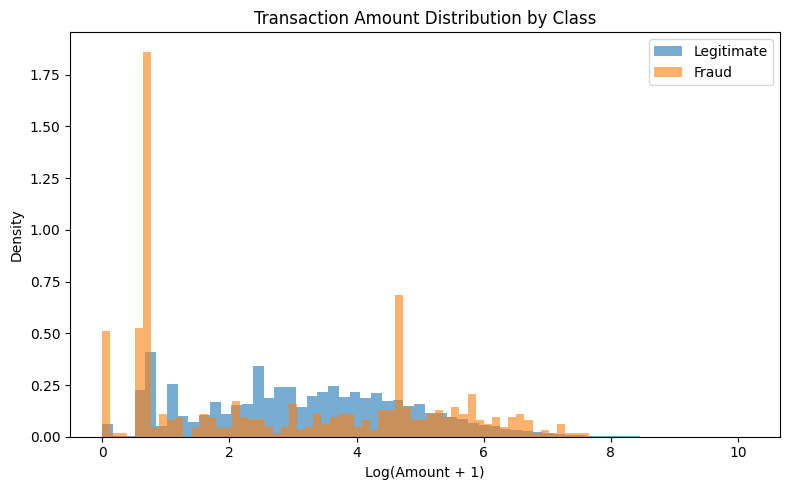

In [ ]:
# Amount distribution by class
# ==> Considering that  the raw amount distribution is highly skewed, using a log transformation only for visualization:

df["LogAmount"] = np.log1p(df["Amount"])

plt.figure(figsize=(8, 5))

plt.hist(
    df.loc[df["Class"] == 0, "LogAmount"],
    bins=60,
    alpha=0.6,
    label="Legitimate",
    density=True
)

plt.hist(
    df.loc[df["Class"] == 1, "LogAmount"],
    bins=60,
    alpha=0.6,
    label="Fraud",
    density=True
)

plt.title("Transaction Amount Distribution by Class")
plt.xlabel("Log(Amount + 1)")
plt.ylabel("Density")
plt.legend()

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "amount_distribution_by_class.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

#Note: LogAmount here is just for EDA. We are not yet deciding whether to use it as a model feature.

In [14]:
# Fraud rate by transaction amount
#==> comparing means and medians as well:

amount_summary = df.groupby("Class")["Amount"].agg(
    ["count", "mean", "median", "min", "max"]
)

amount_summary.index = ["Legitimate", "Fraud"]

print(amount_summary)

             count        mean  median  min       max
Legitimate  284315   88.291022   22.00  0.0  25691.16
Fraud          492  122.211321    9.25  0.0   2125.87


In [15]:
amount_summary.to_csv(
    RESULTS_DIR / "amount_summary_by_class.csv"
)

print("Saved: amount_summary_by_class.csv")

Saved: amount_summary_by_class.csv


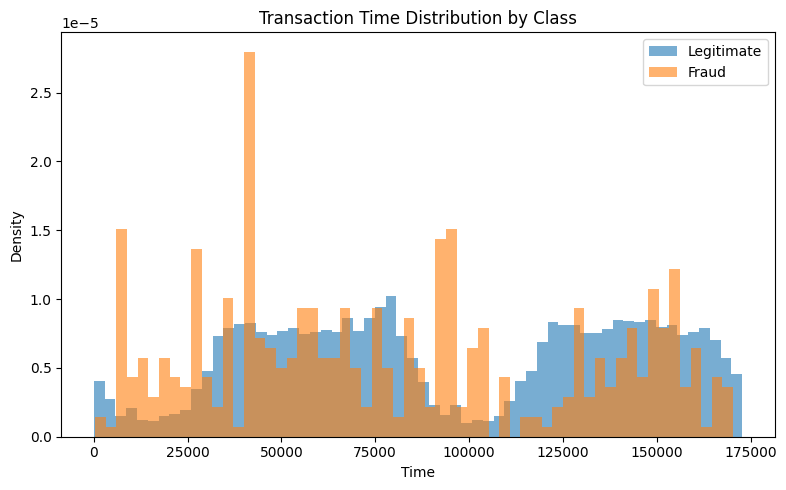

In [16]:
# Time Distribution

plt.figure(figsize=(8, 5))

plt.hist(
    df.loc[df["Class"] == 0, "Time"],
    bins=60,
    alpha=0.6,
    label="Legitimate",
    density=True
)

plt.hist(
    df.loc[df["Class"] == 1, "Time"],
    bins=60,
    alpha=0.6,
    label="Fraud",
    density=True
)

plt.title("Transaction Time Distribution by Class")
plt.xlabel("Time")
plt.ylabel("Density")
plt.legend()

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "time_distribution_by_class.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [17]:
# Correlation with fraud target

correlations = (
    df.drop(columns=["LogAmount"])
    .corr(numeric_only=True)["Class"]
    .drop("Class")
    .sort_values()
)

print("Strongest negative correlations:")
print(correlations.head(10))

print("\nStrongest positive correlations:")
print(correlations.tail(10))

Strongest negative correlations:
V17   -0.326481
V14   -0.302544
V12   -0.260593
V10   -0.216883
V16   -0.196539
V3    -0.192961
V7    -0.187257
V18   -0.111485
V1    -0.101347
V9    -0.097733
Name: Class, dtype: float64

Strongest positive correlations:
Amount    0.005632
V28       0.009536
V27       0.017580
V8        0.019875
V20       0.020090
V19       0.034783
V21       0.040413
V2        0.091289
V4        0.133447
V11       0.154876
Name: Class, dtype: float64


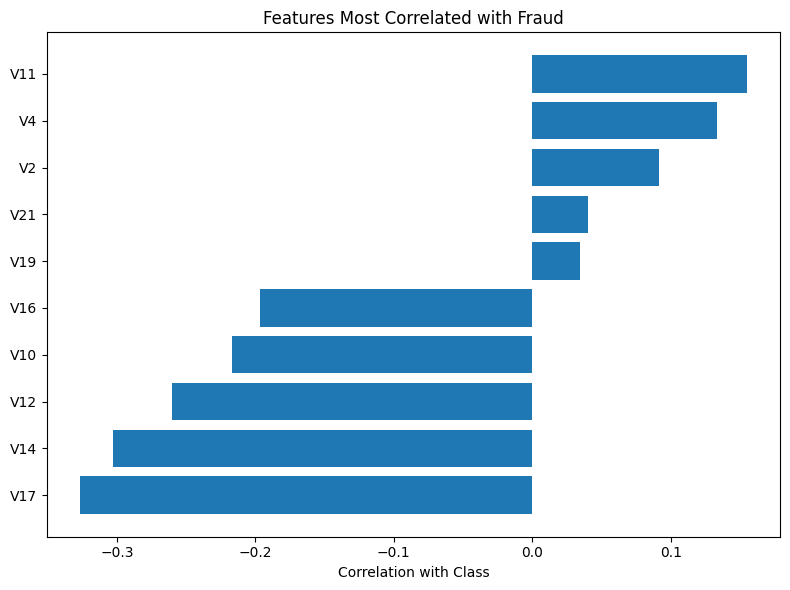

In [ ]:
# Plotting strongest correlations

strongest_features = pd.concat([
    correlations.head(5),
    correlations.tail(5)
]).sort_values()

plt.figure(figsize=(8, 6))
plt.barh(
    strongest_features.index,
    strongest_features.values
)

plt.title("Features Most Correlated with Fraud")
plt.xlabel("Correlation with Class")

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "top_feature_correlations.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# Note: correlation does not mean feature importance. 
# Later, SHAP will give us a much stronger explanation of model behavior.

In [20]:
# Inspect duplicates by class

# Before deciding whether to remove duplicates, checking whether fraud cases are affected:

duplicate_rows = df[df.duplicated(keep=False)]

print("Total duplicate-related rows:", len(duplicate_rows))

print("\nDuplicate-related rows by class:")
print(
    duplicate_rows["Class"]
    .value_counts()
    .sort_index()
)

Total duplicate-related rows: 1854

Duplicate-related rows by class:
Class
0    1822
1      32
Name: count, dtype: int64


In [21]:
# checking the exact duplicate counts among fraud cases:

fraud_duplicates = df[
    (df["Class"] == 1) &
    (df.duplicated())
]

normal_duplicates = df[
    (df["Class"] == 0) &
    (df.duplicated())
]

print("Duplicated legitimate rows:", len(normal_duplicates))
print("Duplicated fraud rows:", len(fraud_duplicates))

Duplicated legitimate rows: 1062
Duplicated fraud rows: 19


In [24]:
# CLEANING THE DATASET

# Remove the temporary EDA-only LogAmount column
# and remove exact duplicate rows

df_clean = (
    df
    .drop(columns=["LogAmount"], errors="ignore")
    .drop_duplicates()
    .reset_index(drop=True)
)

print("Original shape:", df.shape)
print("Cleaned shape:", df_clean.shape)

print("\nClass counts after duplicate removal:")
print(df_clean["Class"].value_counts().sort_index())

print("\nFraud percentage after cleaning:")
print(
    df_clean["Class"].value_counts(normalize=True)
    .sort_index() * 100
)

print("\nRemaining duplicated rows:",
      df_clean.duplicated().sum())

print("Remaining missing values:",
      df_clean.isnull().sum().sum())

Original shape: (284807, 32)
Cleaned shape: (283726, 31)

Class counts after duplicate removal:
Class
0    283253
1       473
Name: count, dtype: int64

Fraud percentage after cleaning:
Class
0    99.83329
1     0.16671
Name: proportion, dtype: float64

Remaining duplicated rows: 0
Remaining missing values: 0


In [ ]:
CLEAN_DATA_PATH = PROJECT_DIR / "creditcard_clean.csv"

df_clean.to_csv(
    CLEAN_DATA_PATH,
    index=False
)

print("Cleaned dataset saved to:")
print(CLEAN_DATA_PATH)


# This gives us a permanent cleaned version while preserving your original creditcard.csv.
# Then create the feature matrix and target:

Cleaned dataset saved to:
C:\Users\eliya\Pictures\Own Research\creditcard_clean.csv


In [26]:
X = df_clean.drop(columns=["Class"])
y = df_clean["Class"]

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

print("\nTarget distribution:")
print(y.value_counts())

Feature matrix shape: (283726, 30)
Target shape: (283726,)

Target distribution:
Class
0    283253
1       473
Name: count, dtype: int64


In [27]:
# STEP 04:  creating the stratified Training / Validation / Conformal Calibration / Final Test sets without leakage.

# Create Train / Validation / Calibration / Test Sets

#We want four separate datasets:

#- Training: 60%

#- Validation: 15%

#- Conformal calibration: 10%

#- Final test: 15%

#We must keep them stratified so each contains fraud cases.

from sklearn.model_selection import train_test_split

# First split: 60% train, 40% temporary
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.40,
    stratify=y,
    random_state=RANDOM_STATE
)

# Split temporary set into:
# 15% validation
# 10% calibration
# 15% test
#
# From the 40% temporary portion:
# validation = 15/40 = 0.375
# calibration + test = 25/40 = 0.625

X_val, X_remaining, y_val, y_remaining = train_test_split(
    X_temp,
    y_temp,
    test_size=0.625,
    stratify=y_temp,
    random_state=RANDOM_STATE
)

# Remaining 25% of total dataset must be split:
# 10% calibration
# 15% test
#
# calibration share inside remaining = 10/25 = 0.40
# test share inside remaining = 15/25 = 0.60

X_cal, X_test, y_cal, y_test = train_test_split(
    X_remaining,
    y_remaining,
    test_size=0.60,
    stratify=y_remaining,
    random_state=RANDOM_STATE
)


In [28]:
# Verifying the Sizes:

print("Train:", X_train.shape, y_train.shape)
print("Validation:", X_val.shape, y_val.shape)
print("Calibration:", X_cal.shape, y_cal.shape)
print("Test:", X_test.shape, y_test.shape)

Train: (170235, 30) (170235,)
Validation: (42559, 30) (42559,)
Calibration: (28372, 30) (28372,)
Test: (42560, 30) (42560,)


In [29]:
# Then verifying fraud counts:

splits = {
    "Train": y_train,
    "Validation": y_val,
    "Calibration": y_cal,
    "Test": y_test
}

for name, y_split in splits.items():
    print(f"\n{name}")
    print(y_split.value_counts().sort_index())

    fraud_rate = y_split.mean() * 100
    print(f"Fraud rate: {fraud_rate:.4f}%")




Train
Class
0    169951
1       284
Name: count, dtype: int64
Fraud rate: 0.1668%

Validation
Class
0    42488
1       71
Name: count, dtype: int64
Fraud rate: 0.1668%

Calibration
Class
0    28325
1       47
Name: count, dtype: int64
Fraud rate: 0.1657%

Test
Class
0    42489
1       71
Name: count, dtype: int64
Fraud rate: 0.1668%


In [ ]:
# Also verifying total row count:

total_split_rows = (
    len(X_train)
    + len(X_val)
    + len(X_cal)
    + len(X_test)
)

print("Total rows across splits:", total_split_rows)
print("Original cleaned rows:", len(df_clean))

# These two numbers must match:

Total rows across splits: 283726
Original cleaned rows: 283726


In [31]:
#============================
# Saving  Split Summary:
#============================

split_summary = pd.DataFrame({
    "Split": ["Train", "Validation", "Calibration", "Test"],
    "Rows": [
        len(X_train),
        len(X_val),
        len(X_cal),
        len(X_test)
    ],
    "Fraud Cases": [
        y_train.sum(),
        y_val.sum(),
        y_cal.sum(),
        y_test.sum()
    ],
    "Fraud Rate (%)": [
        y_train.mean() * 100,
        y_val.mean() * 100,
        y_cal.mean() * 100,
        y_test.mean() * 100
    ]
})

print(split_summary)

split_summary.to_csv(
    RESULTS_DIR / "data_split_summary.csv",
    index=False
)

         Split    Rows  Fraud Cases  Fraud Rate (%)
0        Train  170235          284        0.166828
1   Validation   42559           71        0.166827
2  Calibration   28372           47        0.165656
3         Test   42560           71        0.166823


In [32]:
# STEP 05: 
#====================================================
# Step 5A — Build the Logistic Regression pipeline
#====================================================

# For Logistic Regression, we should scale the features. 
# We will use StandardScaler inside a pipeline so preprocessing happens correctly and reproducibly.


from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

logistic_model = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression(
        class_weight="balanced",
        max_iter=2000,
        random_state=RANDOM_STATE
    ))
])

print(logistic_model)

Pipeline(steps=[('scaler', StandardScaler()),
                ('classifier',
                 LogisticRegression(class_weight='balanced', max_iter=2000,
                                    random_state=42))])


In [33]:
# Step 5B — Train the model

logistic_model.fit(X_train, y_train)

print("Logistic Regression training completed.")

Logistic Regression training completed.


In [34]:
# Step 5C — Generate validation probabilities
# We will not evaluate on the test set yet.

logistic_val_prob = logistic_model.predict_proba(X_val)[:, 1]

print("Validation probabilities generated.")
print("Minimum probability:", logistic_val_prob.min())
print("Maximum probability:", logistic_val_prob.max())

Validation probabilities generated.
Minimum probability: 9.029617835872298e-37
Maximum probability: 1.0


In [35]:
# Step 5D — Evaluate default threshold 0.50

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix
)

default_threshold = 0.50

logistic_val_pred_default = (
    logistic_val_prob >= default_threshold
).astype(int)

logistic_default_results = {
    "Accuracy": accuracy_score(
        y_val,
        logistic_val_pred_default
    ),
    "Precision": precision_score(
        y_val,
        logistic_val_pred_default,
        zero_division=0
    ),
    "Recall": recall_score(
        y_val,
        logistic_val_pred_default,
        zero_division=0
    ),
    "F1": f1_score(
        y_val,
        logistic_val_pred_default,
        zero_division=0
    ),
    "ROC_AUC": roc_auc_score(
        y_val,
        logistic_val_prob
    ),
    "PR_AUC": average_precision_score(
        y_val,
        logistic_val_prob
    )
}

print("Logistic Regression — Validation Results")
for metric, value in logistic_default_results.items():
    print(f"{metric}: {value:.6f}")

Logistic Regression — Validation Results
Accuracy: 0.977044
Precision: 0.057617
Recall: 0.830986
F1: 0.107763
ROC_AUC: 0.971330
PR_AUC: 0.677270


In [36]:
# Step 5E — Confusion matrix

cm = confusion_matrix(
    y_val,
    logistic_val_pred_default
)

print("Confusion Matrix:")
print(cm)

tn, fp, fn, tp = cm.ravel()

print("\nTrue Negatives:", tn)
print("False Positives:", fp)
print("False Negatives:", fn)
print("True Positives:", tp)

Confusion Matrix:
[[41523   965]
 [   12    59]]

True Negatives: 41523
False Positives: 965
False Negatives: 12
True Positives: 59


In [37]:
# Step 5F — Threshold optimization
# Because 0.50 is rarely optimal for a dataset this imbalanced, 
# we’ll choose a better threshold using only the validation set.

from sklearn.metrics import precision_recall_curve

precision_vals, recall_vals, thresholds = precision_recall_curve(
    y_val,
    logistic_val_prob
)

f1_vals = (
    2 * precision_vals[:-1] * recall_vals[:-1]
    / (
        precision_vals[:-1]
        + recall_vals[:-1]
        + 1e-12
    )
)

best_index = np.argmax(f1_vals)

best_threshold_logistic = thresholds[best_index]

print("Best threshold:", best_threshold_logistic)
print("Best validation F1:", f1_vals[best_index])
print("Precision at best threshold:", precision_vals[best_index])
print("Recall at best threshold:", recall_vals[best_index])

Best threshold: 0.9999963455554165
Best validation F1: 0.7878787878782908
Precision at best threshold: 0.8524590163934426
Recall at best threshold: 0.7323943661971831


In [38]:
# Step 5G — Evaluate optimized threshold

logistic_val_pred_opt = (
    logistic_val_prob >= best_threshold_logistic
).astype(int)

logistic_optimized_results = {
    "Accuracy": accuracy_score(
        y_val,
        logistic_val_pred_opt
    ),
    "Precision": precision_score(
        y_val,
        logistic_val_pred_opt,
        zero_division=0
    ),
    "Recall": recall_score(
        y_val,
        logistic_val_pred_opt,
        zero_division=0
    ),
    "F1": f1_score(
        y_val,
        logistic_val_pred_opt,
        zero_division=0
    ),
    "ROC_AUC": roc_auc_score(
        y_val,
        logistic_val_prob
    ),
    "PR_AUC": average_precision_score(
        y_val,
        logistic_val_prob
    )
}

print("Logistic Regression — Optimized Validation Results")

for metric, value in logistic_optimized_results.items():
    print(f"{metric}: {value:.6f}")

Logistic Regression — Optimized Validation Results
Accuracy: 0.999342
Precision: 0.852459
Recall: 0.732394
F1: 0.787879
ROC_AUC: 0.971330
PR_AUC: 0.677270


In [39]:
cm_opt = confusion_matrix(
    y_val,
    logistic_val_pred_opt
)

print("Optimized Confusion Matrix:")
print(cm_opt)

Optimized Confusion Matrix:
[[42479     9]
 [   19    52]]


In [ ]:
#These results are very informative, and they confirm why threshold tuning matters so much for this dataset.
# At the default threshold of 0.50, Logistic Regression catches 59 of 71 fraud cases with recall 0.831, but it also creates 965 false positives. That drives precision down to only 0.0576. So the model is sensitive, but far too aggressive.
# After threshold optimization, the picture changes dramatically:
#- Precision: 0.8525
#- Recall: 0.7324
#- F1: 0.7879
#- False positives: 9
#- False negatives: 19
#- True positives: 52
#So the tuned model is much more operationally realistic.
#The odd-looking part is the optimized threshold: 0.999996. That is not necessarily an error. Because we trained Logistic Regression with class_weight="balanced", its raw predicted probabilities are often not well calibrated as real probabilities. The weighting shifts the decision boundary and can produce extreme scores. This is exactly why our later calibration analysis is important.
#The ranking metrics are unchanged by the threshold, as expected:
#- ROC-AUC: 0.9713
#- PR-AUC: 0.6773

#PR-AUC is the more meaningful one for this highly imbalanced problem.
#The confusion matrices show the trade-off very clearly:

#Default threshold 0.50
#TN = 41523
#FP =   965
#FN =    12
#TP =    59

#Optimized threshold
#TN = 42479
#FP =     9
#FN =    19
#TP =    52


#One methodological caution: do not yet call 0.999996 the final production threshold. 
#We will compare all models first and later inspect calibration. For now it is simply the validation-optimal F1 threshold for Logistic Regression.

In [40]:
#==================================
# Step 6 — Random Forest
#==================================

from sklearn.ensemble import RandomForestClassifier

random_forest_model = RandomForestClassifier(
    n_estimators=300,
    class_weight="balanced",
    random_state=RANDOM_STATE,
    n_jobs=-1
)

random_forest_model.fit(X_train, y_train)

print("Random Forest training completed.")

Random Forest training completed.


In [41]:
#  Then generate validation probabilities:

rf_val_prob = random_forest_model.predict_proba(X_val)[:, 1]

print("Minimum probability:", rf_val_prob.min())
print("Maximum probability:", rf_val_prob.max())

Minimum probability: 0.0
Maximum probability: 1.0


In [42]:
# Evaluate at 0.50:

rf_val_pred_default = (
    rf_val_prob >= 0.50
).astype(int)

rf_default_results = {
    "Accuracy": accuracy_score(y_val, rf_val_pred_default),
    "Precision": precision_score(
        y_val, rf_val_pred_default, zero_division=0
    ),
    "Recall": recall_score(
        y_val, rf_val_pred_default, zero_division=0
    ),
    "F1": f1_score(
        y_val, rf_val_pred_default, zero_division=0
    ),
    "ROC_AUC": roc_auc_score(
        y_val, rf_val_prob
    ),
    "PR_AUC": average_precision_score(
        y_val, rf_val_prob
    )
}

print("Random Forest — Validation Results")

for metric, value in rf_default_results.items():
    print(f"{metric}: {value:.6f}")

Random Forest — Validation Results
Accuracy: 0.999389
Precision: 0.941176
Recall: 0.676056
F1: 0.786885
ROC_AUC: 0.932408
PR_AUC: 0.774533


In [43]:
# Confusion Matrix:

rf_cm_default = confusion_matrix(
    y_val,
    rf_val_pred_default
)

print("Default Confusion Matrix:")
print(rf_cm_default)

Default Confusion Matrix:
[[42485     3]
 [   23    48]]


In [44]:
# Then optimize the threshold exactly as we did for Logistic Regression:

rf_precision_vals, rf_recall_vals, rf_thresholds = (
    precision_recall_curve(
        y_val,
        rf_val_prob
    )
)

rf_f1_vals = (
    2
    * rf_precision_vals[:-1]
    * rf_recall_vals[:-1]
    / (
        rf_precision_vals[:-1]
        + rf_recall_vals[:-1]
        + 1e-12
    )
)

rf_best_index = np.argmax(rf_f1_vals)

best_threshold_rf = rf_thresholds[rf_best_index]

print("Best threshold:", best_threshold_rf)
print("Best validation F1:", rf_f1_vals[rf_best_index])
print(
    "Precision at best threshold:",
    rf_precision_vals[rf_best_index]
)
print(
    "Recall at best threshold:",
    rf_recall_vals[rf_best_index]
)

Best threshold: 0.28
Best validation F1: 0.8281249999995058
Precision at best threshold: 0.9298245614035088
Recall at best threshold: 0.7464788732394366


In [45]:
# And evaluating it:

rf_val_pred_opt = (
    rf_val_prob >= best_threshold_rf
).astype(int)

rf_optimized_results = {
    "Accuracy": accuracy_score(
        y_val, rf_val_pred_opt
    ),
    "Precision": precision_score(
        y_val, rf_val_pred_opt, zero_division=0
    ),
    "Recall": recall_score(
        y_val, rf_val_pred_opt, zero_division=0
    ),
    "F1": f1_score(
        y_val, rf_val_pred_opt, zero_division=0
    ),
    "ROC_AUC": roc_auc_score(
        y_val, rf_val_prob
    ),
    "PR_AUC": average_precision_score(
        y_val, rf_val_prob
    )
}

print("Random Forest — Optimized Validation Results")

for metric, value in rf_optimized_results.items():
    print(f"{metric}: {value:.6f}")

rf_cm_opt = confusion_matrix(
    y_val,
    rf_val_pred_opt
)

print("\nOptimized Confusion Matrix:")
print(rf_cm_opt)

Random Forest — Optimized Validation Results
Accuracy: 0.999483
Precision: 0.929825
Recall: 0.746479
F1: 0.828125
ROC_AUC: 0.932408
PR_AUC: 0.774533

Optimized Confusion Matrix:
[[42484     4]
 [   18    53]]


In [46]:
#=========================================
# Step 7 — XGBoost
#=========================================

# For XGBoost, we should not arbitrarily set the class imbalance weight.
#We'll calculate it directly from the training data:

negative_count = (y_train == 0).sum()
positive_count = (y_train == 1).sum()

scale_pos_weight = negative_count / positive_count

print("Training legitimate cases:", negative_count)
print("Training fraud cases:", positive_count)
print("scale_pos_weight:", scale_pos_weight)

Training legitimate cases: 169951
Training fraud cases: 284
scale_pos_weight: 598.419014084507


In [47]:
#  Building XGBoost:

from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=400,
    max_depth=4,
    learning_rate=0.03,
    subsample=0.9,
    colsample_bytree=0.9,
    scale_pos_weight=scale_pos_weight,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=RANDOM_STATE,
    n_jobs=-1
)

xgb_model.fit(
    X_train,
    y_train
)

print("XGBoost training completed.")



XGBoost training completed.


In [48]:
# Generating validation probabilities:

xgb_val_prob = xgb_model.predict_proba(X_val)[:, 1]

print("Minimum probability:", xgb_val_prob.min())
print("Maximum probability:", xgb_val_prob.max())



Minimum probability: 1.2227865e-05
Maximum probability: 0.99986744


In [49]:
# Evaluate the default 0.50 threshold:

xgb_val_pred_default = (
    xgb_val_prob >= 0.50
).astype(int)

xgb_default_results = {
    "Accuracy": accuracy_score(
        y_val,
        xgb_val_pred_default
    ),
    "Precision": precision_score(
        y_val,
        xgb_val_pred_default,
        zero_division=0
    ),
    "Recall": recall_score(
        y_val,
        xgb_val_pred_default,
        zero_division=0
    ),
    "F1": f1_score(
        y_val,
        xgb_val_pred_default,
        zero_division=0
    ),
    "ROC_AUC": roc_auc_score(
        y_val,
        xgb_val_prob
    ),
    "PR_AUC": average_precision_score(
        y_val,
        xgb_val_prob
    )
}

print("XGBoost — Validation Results")

for metric, value in xgb_default_results.items():
    print(f"{metric}: {value:.6f}")

xgb_cm_default = confusion_matrix(
    y_val,
    xgb_val_pred_default
)

print("\nDefault Confusion Matrix:")
print(xgb_cm_default)

XGBoost — Validation Results
Accuracy: 0.998661
Precision: 0.571429
Recall: 0.788732
F1: 0.662722
ROC_AUC: 0.962666
PR_AUC: 0.761911

Default Confusion Matrix:
[[42446    42]
 [   15    56]]


In [50]:
# Then optimizing the threshold:

xgb_precision_vals, xgb_recall_vals, xgb_thresholds = (
    precision_recall_curve(
        y_val,
        xgb_val_prob
    )
)

xgb_f1_vals = (
    2
    * xgb_precision_vals[:-1]
    * xgb_recall_vals[:-1]
    / (
        xgb_precision_vals[:-1]
        + xgb_recall_vals[:-1]
        + 1e-12
    )
)

xgb_best_index = np.argmax(xgb_f1_vals)

best_threshold_xgb = xgb_thresholds[xgb_best_index]

print("Best threshold:", best_threshold_xgb)
print("Best validation F1:", xgb_f1_vals[xgb_best_index])
print(
    "Precision at best threshold:",
    xgb_precision_vals[xgb_best_index]
)
print(
    "Recall at best threshold:",
    xgb_recall_vals[xgb_best_index]
)

Best threshold: 0.8904976
Best validation F1: 0.824427480915534
Precision at best threshold: 0.9
Recall at best threshold: 0.7605633802816901


In [51]:
# Finally

xgb_val_pred_opt = (
    xgb_val_prob >= best_threshold_xgb
).astype(int)

xgb_optimized_results = {
    "Accuracy": accuracy_score(
        y_val,
        xgb_val_pred_opt
    ),
    "Precision": precision_score(
        y_val,
        xgb_val_pred_opt,
        zero_division=0
    ),
    "Recall": recall_score(
        y_val,
        xgb_val_pred_opt,
        zero_division=0
    ),
    "F1": f1_score(
        y_val,
        xgb_val_pred_opt,
        zero_division=0
    ),
    "ROC_AUC": roc_auc_score(
        y_val,
        xgb_val_prob
    ),
    "PR_AUC": average_precision_score(
        y_val,
        xgb_val_prob
    )
}

print("XGBoost — Optimized Validation Results")

for metric, value in xgb_optimized_results.items():
    print(f"{metric}: {value:.6f}")

xgb_cm_opt = confusion_matrix(
    y_val,
    xgb_val_pred_opt
)

print("\nOptimized Confusion Matrix:")
print(xgb_cm_opt)

XGBoost — Optimized Validation Results
Accuracy: 0.999460
Precision: 0.900000
Recall: 0.760563
F1: 0.824427
ROC_AUC: 0.962666
PR_AUC: 0.761911

Optimized Confusion Matrix:
[[42482     6]
 [   17    54]]


These XGBoost results make sense, and the numbers are internally consistent. Nothing here looks suspicious.

At the default threshold of **0.50**, your confusion matrix is:

```text
TN = 42,446
FP = 42
FN = 15
TP = 56
```

That gives:

- Precision = 56 / (56 + 42) = **0.5714**
- Recall = 56 / (56 + 15) = **0.7887**
- F1 = **0.6627**

So at 0.50, XGBoost is catching many frauds, but it is producing too many false positives.

After threshold tuning to **0.8905**, the confusion matrix becomes:

```text
TN = 42,482
FP = 6
FN = 17
TP = 54
```

Now:

- Precision = **0.9000**
- Recall = **0.7606**
- F1 = **0.8244**

That is a much better operating point.

The threshold rising from 0.50 to about **0.89** is also reasonable here because `scale_pos_weight ≈ 598.4` heavily reweights the fraud class during training. That improves minority-class learning, but it also means the raw output scores should not automatically be interpreted as perfectly calibrated probabilities.

The important comparison now is this:

| Model | Best Threshold | Precision | Recall | F1 | ROC-AUC | PR-AUC |
|---|---:|---:|---:|---:|---:|---:|
| Logistic Regression | ~0.999996 | 0.8525 | 0.7324 | 0.7879 | **0.9713** | 0.6773 |
| Random Forest | 0.28 | **0.9298** | 0.7465 | **0.8281** | 0.9324 | **0.7745** |
| XGBoost | 0.8905 | 0.9000 | **0.7606** | 0.8244 | 0.9627 | 0.7619 |

So at this stage, **Random Forest is still slightly ahead overall**, mainly because it has:

- the highest PR-AUC: **0.7745**
- the highest F1: **0.8281**
- the highest precision: **0.9298**

But XGBoost has the highest recall among the optimized models:

- XGBoost recall: **0.7606**
- Random Forest recall: **0.7465**

That means XGBoost catches one more fraud case than Random Forest in this validation split:

- RF: 53 / 71 frauds detected
- XGB: 54 / 71 frauds detected

but XGBoost also produces:

- 6 false positives

versus Random Forest:

- 4 false positives

So the difference between them is tiny.

This is important: **we should not claim that Random Forest is definitively better just because F1 is 0.8281 vs 0.8244.** With only 71 fraud cases in the validation set, that difference can be caused by only one or two transactions.

So for the paper, the correct language later would be something like:

> Random Forest and XGBoost produced comparable validation performance, with Random Forest achieving slightly higher PR-AUC and F1-score, while XGBoost achieved slightly higher fraud recall.

That is much more defensible.

There is also an interesting model behavior difference. Logistic Regression has the best ROC-AUC, but the worst PR-AUC. Random Forest has the best PR-AUC despite the lowest ROC-AUC. For this extremely imbalanced dataset, **PR-AUC is more informative for the minority fraud class**, so Random Forest currently looks stronger for our actual task.

Before we move to SHAP or conformal prediction, I recommend one important intermediate step: create a **formal three-model validation comparison table**, save it, and then run a small overfitting check by comparing training metrics against validation metrics. After that, we can choose the primary model with much more confidence.



In [52]:
#=================================================
# Step 8 — Three-model validation comparison
#=================================================

# Doing the formal three-model comparison + overfitting check before choosing the primary model.


model_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "XGBoost"
    ],
    "Best Threshold": [
        best_threshold_logistic,
        best_threshold_rf,
        best_threshold_xgb
    ],
    "Precision": [
        logistic_optimized_results["Precision"],
        rf_optimized_results["Precision"],
        xgb_optimized_results["Precision"]
    ],
    "Recall": [
        logistic_optimized_results["Recall"],
        rf_optimized_results["Recall"],
        xgb_optimized_results["Recall"]
    ],
    "F1": [
        logistic_optimized_results["F1"],
        rf_optimized_results["F1"],
        xgb_optimized_results["F1"]
    ],
    "ROC_AUC": [
        logistic_optimized_results["ROC_AUC"],
        rf_optimized_results["ROC_AUC"],
        xgb_optimized_results["ROC_AUC"]
    ],
    "PR_AUC": [
        logistic_optimized_results["PR_AUC"],
        rf_optimized_results["PR_AUC"],
        xgb_optimized_results["PR_AUC"]
    ]
})

model_comparison

,Model,Best Threshold,Precision,Recall,F1,ROC_AUC,PR_AUC
0,Logistic Regression,0.999996,0.852459,0.732394,0.787879,0.971330,0.677270
1,Random Forest,0.280000,0.929825,0.746479,0.828125,0.932408,0.774533
2,XGBoost,0.890498,0.900000,0.760563,0.824427,0.962666,0.761911


In [53]:
# Then Saving it:

model_comparison.to_csv(
    RESULTS_DIR / "validation_model_comparison.csv",
    index=False
)

print("Saved: validation_model_comparison.csv")

Saved: validation_model_comparison.csv


In [54]:

#=======================================
# Step 9 — Check for overfitting
#=======================================

# We should compare training vs validation performance for all three models.


## Logistic Regression

logistic_train_prob = logistic_model.predict_proba(X_train)[:, 1]

logistic_train_pred = (
    logistic_train_prob >= best_threshold_logistic
).astype(int)

logistic_train_metrics = {
    "Precision": precision_score(
        y_train, logistic_train_pred, zero_division=0
    ),
    "Recall": recall_score(
        y_train, logistic_train_pred, zero_division=0
    ),
    "F1": f1_score(
        y_train, logistic_train_pred, zero_division=0
    ),
    "ROC_AUC": roc_auc_score(
        y_train, logistic_train_prob
    ),
    "PR_AUC": average_precision_score(
        y_train, logistic_train_prob
    )
}

print("Logistic Regression — Training Metrics")
for k, v in logistic_train_metrics.items():
    print(f"{k}: {v:.6f}")

Logistic Regression — Training Metrics
Precision: 0.802158
Recall: 0.785211
F1: 0.793594
ROC_AUC: 0.991049
PR_AUC: 0.746463


In [55]:
# Random Forest

rf_train_prob = random_forest_model.predict_proba(X_train)[:, 1]

rf_train_pred = (
    rf_train_prob >= best_threshold_rf
).astype(int)

rf_train_metrics = {
    "Precision": precision_score(
        y_train, rf_train_pred, zero_division=0
    ),
    "Recall": recall_score(
        y_train, rf_train_pred, zero_division=0
    ),
    "F1": f1_score(
        y_train, rf_train_pred, zero_division=0
    ),
    "ROC_AUC": roc_auc_score(
        y_train, rf_train_prob
    ),
    "PR_AUC": average_precision_score(
        y_train, rf_train_prob
    )
}

print("Random Forest — Training Metrics")
for k, v in rf_train_metrics.items():
    print(f"{k}: {v:.6f}")

Random Forest — Training Metrics
Precision: 0.982699
Recall: 1.000000
F1: 0.991274
ROC_AUC: 1.000000
PR_AUC: 1.000000


In [56]:
# XGBoost


xgb_train_prob = xgb_model.predict_proba(X_train)[:, 1]

xgb_train_pred = (
    xgb_train_prob >= best_threshold_xgb
).astype(int)

xgb_train_metrics = {
    "Precision": precision_score(
        y_train, xgb_train_pred, zero_division=0
    ),
    "Recall": recall_score(
        y_train, xgb_train_pred, zero_division=0
    ),
    "F1": f1_score(
        y_train, xgb_train_pred, zero_division=0
    ),
    "ROC_AUC": roc_auc_score(
        y_train, xgb_train_prob
    ),
    "PR_AUC": average_precision_score(
        y_train, xgb_train_prob
    )
}

print("XGBoost — Training Metrics")
for k, v in xgb_train_metrics.items():
    print(f"{k}: {v:.6f}")

XGBoost — Training Metrics
Precision: 0.919094
Recall: 1.000000
F1: 0.957841
ROC_AUC: 0.999972
PR_AUC: 0.976779


In [57]:
#==================================================================
# Step 10 — Build train-vs-validation table
#==================================================================

overfitting_check = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "XGBoost"
    ],

    "Train F1": [
        logistic_train_metrics["F1"],
        rf_train_metrics["F1"],
        xgb_train_metrics["F1"]
    ],

    "Validation F1": [
        logistic_optimized_results["F1"],
        rf_optimized_results["F1"],
        xgb_optimized_results["F1"]
    ],

    "Train ROC_AUC": [
        logistic_train_metrics["ROC_AUC"],
        rf_train_metrics["ROC_AUC"],
        xgb_train_metrics["ROC_AUC"]
    ],

    "Validation ROC_AUC": [
        logistic_optimized_results["ROC_AUC"],
        rf_optimized_results["ROC_AUC"],
        xgb_optimized_results["ROC_AUC"]
    ],

    "Train PR_AUC": [
        logistic_train_metrics["PR_AUC"],
        rf_train_metrics["PR_AUC"],
        xgb_train_metrics["PR_AUC"]
    ],

    "Validation PR_AUC": [
        logistic_optimized_results["PR_AUC"],
        rf_optimized_results["PR_AUC"],
        xgb_optimized_results["PR_AUC"]
    ]
})

overfitting_check

,Model,Train F1,Validation F1,Train ROC_AUC,Validation ROC_AUC,Train PR_AUC,Validation PR_AUC
0,Logistic Regression,0.793594,0.787879,0.991049,0.971330,0.746463,0.677270
1,Random Forest,0.991274,0.828125,1.000000,0.932408,1.000000,0.774533
2,XGBoost,0.957841,0.824427,0.999972,0.962666,0.976779,0.761911


In [58]:
# Saving it:

overfitting_check.to_csv(
    RESULTS_DIR / "train_validation_overfitting_check.csv",
    index=False
)

How we will interpret it
If Random Forest shows something like:

Train PR-AUC ≈ 1.00
Validation PR-AUC ≈ 0.77


then it is clearly fitting the training set much more strongly than the validation set.
That does not automatically invalidate it, but it would be evidence of overfitting.
If XGBoost has a smaller train-validation gap, then we may prefer XGBoost even if its validation F1 is slightly lower.
That is why we are doing this check before choosing the final model.
Send me:
- the model_comparison table
- Logistic training metrics
- Random Forest training metrics
- XGBoost training metrics
- overfitting_check table
Then I’ll tell you which model is the most defensible primary model for the research.

These results are very useful, because now we can actually diagnose the models rather than choosing one just because it has the highest validation F1.

The key finding is: **Random Forest is currently overfitting quite strongly. XGBoost is also overfitting, but less severely. Logistic Regression generalizes best, but its fraud-detection performance is weaker.**

Here is the clean interpretation:

| Model | Train F1 | Val F1 | F1 gap | Train PR-AUC | Val PR-AUC | PR-AUC gap |
|---|---:|---:|---:|---:|---:|---:|
| Logistic Regression | 0.7936 | 0.7879 | **0.0057** | 0.7465 | 0.6773 | **0.0692** |
| Random Forest | 0.9913 | 0.8281 | **0.1631** | 1.0000 | 0.7745 | **0.2255** |
| XGBoost | 0.9578 | 0.8244 | **0.1334** | 0.9768 | 0.7619 | **0.2149** |

So yes, our earlier concern about Random Forest was worth checking.

### What this means

**Logistic Regression** is very stable. Train F1 and validation F1 are almost identical. Its validation ROC-AUC is actually the highest at **0.9713**, but its PR-AUC of **0.6773** is clearly behind the tree models. So it is an excellent baseline, but probably not our final fraud detector.

**Random Forest** fits the training data almost perfectly:

- Train ROC-AUC = **1.000**
- Train PR-AUC = **1.000**
- Train recall = **1.000**

But validation drops to:

- ROC-AUC = **0.9324**
- PR-AUC = **0.7745**
- F1 = **0.8281**

That is clear evidence of overfitting. It does not mean the model is useless—the validation performance is still strong—but I would **not select this exact Random Forest configuration as our final model yet**.

**XGBoost** also fits the training data very strongly:

- Train ROC-AUC = **0.99997**
- Train PR-AUC = **0.9768**

but generalizes somewhat better than Random Forest:

- Validation ROC-AUC = **0.9627**
- Validation PR-AUC = **0.7619**
- Validation F1 = **0.8244**

It also has the highest optimized recall:

**0.7606**

versus Random Forest's:

**0.7465**

So right now, if I had to choose between the two tree models, I would lean toward **XGBoost**, despite Random Forest's slightly better PR-AUC/F1, because XGBoost shows better generalization and better fraud recall.

But for a strong research paper, **we should not choose the final model yet**.

## What we should do next

Instead of moving straight to SHAP and conformal prediction, the proper next step is:

**regularize/tune Random Forest and XGBoost using only the training set**, then evaluate the tuned versions on the validation set.

That will answer an important research question:

> Can we reduce overfitting while preserving strong fraud-detection performance?

That makes the work much more defensible.

We should optimize primarily for **Average Precision / PR-AUC**, not accuracy.

### For Random Forest, we should control

- `max_depth`
- `min_samples_split`
- `min_samples_leaf`
- `max_features`
- possibly `n_estimators`

The current forest has unrestricted depth by default, which is one major reason it can memorize the training data.

### For XGBoost, we should control

- `max_depth`
- `min_child_weight`
- `subsample`
- `colsample_bytree`
- `reg_alpha`
- `reg_lambda`

These explicitly regularize the boosting process.

I would use **3-fold stratified cross-validation on the training set** with `average_precision` as the scoring metric. We won't touch the calibration or test sets.

So our methodology becomes:

```text
Training set
    ↓
Cross-validation / regularization
    ↓
Fit tuned candidate models

Validation set
    ↓
Compare tuned models
    ↓
Tune classification threshold
    ↓
Choose primary model

Calibration set
    ↓
Conformal calibration

Test set
    ↓
One final unbiased evaluation
```

That is a substantially stronger research design than simply choosing the current Random Forest because it has F1 = 0.8281.

### Current conclusion

At this exact moment:

- **Best generalization:** Logistic Regression
- **Best validation PR-AUC:** Random Forest
- **Best validation F1:** Random Forest
- **Best validation recall:** XGBoost
- **Most obvious overfitting:** Random Forest
- **Most promising advanced model overall:** **XGBoost**

So we should now move to **Step 11: controlled hyperparameter tuning/regularization of Random Forest and XGBoost**, and only after that select the model for SHAP and conformal prediction.

In [59]:
#===========================================================================================
# Step 11: controlled hyperparameter tuning/regularization of Random Forest and XGBoost, 
# and only after that select the model for SHAP and conformal prediction.
#============================================================================================


#Step 11A — Tune Random Forest with stratified cross-validation

#We will optimize for Average Precision (PR-AUC), not accuracy.

from sklearn.model_selection import (
    StratifiedKFold,
    RandomizedSearchCV
)

# Stratified CV keeps roughly the same fraud ratio in every fold
cv_strategy = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=RANDOM_STATE
)

print("Cross-validation strategy ready.")

Cross-validation strategy ready.


In [60]:
#  Define a regularized Random Forest

rf_tuning_model = RandomForestClassifier(
    class_weight="balanced",
    random_state=RANDOM_STATE,
    n_jobs=-1
)

In [61]:
# Now defining a controlled search space:

rf_param_distributions = {
    "n_estimators": [200, 300, 400],
    "max_depth": [8, 12, 16, 20, None],
    "min_samples_split": [2, 5, 10, 20],
    "min_samples_leaf": [1, 2, 4, 8],
    "max_features": ["sqrt", "log2", 0.5]
}

The parameters that matter most for reducing overfitting are:
- max_depth
- min_samples_split
- min_samples_leaf

Now run the randomized search:

In [62]:
# Now running the randomized search:

rf_search = RandomizedSearchCV(
    estimator=rf_tuning_model,
    param_distributions=rf_param_distributions,
    n_iter=12,
    scoring="average_precision",
    cv=cv_strategy,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=2,
    return_train_score=True
)

rf_search.fit(X_train, y_train)

Fitting 3 folds for each of 12 candidates, totalling 36 fits


,estimator,RandomForestC...ndom_state=42)
,param_distributions,"{'max_depth': [8, 12, ...], 'max_features': ['sqrt', 'log2', ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], ...}"
,n_iter,12
,scoring,'average_precision'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,2
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [63]:
# Step 11B — Inspect the best Random Forest

print("Best Random Forest parameters:")
print(rf_search.best_params_)

print(
    "\nBest CV Average Precision:",
    rf_search.best_score_
)

Best Random Forest parameters:
{'n_estimators': 300, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': 20}

Best CV Average Precision: 0.8382922999707669


In [64]:
# Then get the best model:

tuned_rf_model = rf_search.best_estimator_

print(tuned_rf_model)

RandomForestClassifier(class_weight='balanced', max_depth=20,
                       min_samples_leaf=2, min_samples_split=5,
                       n_estimators=300, n_jobs=-1, random_state=42)


Step 11C — Check CV train-vs-validation gap
This is very important because we are specifically trying to reduce overfitting.

In [65]:
rf_cv_results = pd.DataFrame(
    rf_search.cv_results_
)

best_rf_index = rf_search.best_index_

print(
    "Best mean CV training PR-AUC:",
    rf_cv_results.loc[
        best_rf_index,
        "mean_train_score"
    ]
)

print(
    "Best mean CV validation PR-AUC:",
    rf_cv_results.loc[
        best_rf_index,
        "mean_test_score"
    ]
)

Best mean CV training PR-AUC: 0.9965923545922695
Best mean CV validation PR-AUC: 0.8382922999707669


Step 11D — Evaluate tuned RF on our held-out validation set
Generate validation probabilities:

In [66]:
tuned_rf_val_prob = (
    tuned_rf_model
    .predict_proba(X_val)[:, 1]
)

In [67]:
# First inspect default threshold:

tuned_rf_val_pred_default = (
    tuned_rf_val_prob >= 0.50
).astype(int)

tuned_rf_default_results = {
    "Accuracy": accuracy_score(
        y_val,
        tuned_rf_val_pred_default
    ),
    "Precision": precision_score(
        y_val,
        tuned_rf_val_pred_default,
        zero_division=0
    ),
    "Recall": recall_score(
        y_val,
        tuned_rf_val_pred_default,
        zero_division=0
    ),
    "F1": f1_score(
        y_val,
        tuned_rf_val_pred_default,
        zero_division=0
    ),
    "ROC_AUC": roc_auc_score(
        y_val,
        tuned_rf_val_prob
    ),
    "PR_AUC": average_precision_score(
        y_val,
        tuned_rf_val_prob
    )
}

print("Tuned Random Forest — Default Threshold")

for metric, value in tuned_rf_default_results.items():
    print(f"{metric}: {value:.6f}")

print(
    "\nConfusion Matrix:"
)

print(
    confusion_matrix(
        y_val,
        tuned_rf_val_pred_default
    )
)

Tuned Random Forest — Default Threshold
Accuracy: 0.999413
Precision: 0.942308
Recall: 0.690141
F1: 0.796748
ROC_AUC: 0.936415
PR_AUC: 0.773611

Confusion Matrix:
[[42485     3]
 [   22    49]]


In [68]:
# Step 11E — Optimize the tuned RF threshold

(
    tuned_rf_precision_vals,
    tuned_rf_recall_vals,
    tuned_rf_thresholds
) = precision_recall_curve(
    y_val,
    tuned_rf_val_prob
)

tuned_rf_f1_vals = (
    2
    * tuned_rf_precision_vals[:-1]
    * tuned_rf_recall_vals[:-1]
    / (
        tuned_rf_precision_vals[:-1]
        + tuned_rf_recall_vals[:-1]
        + 1e-12
    )
)

tuned_rf_best_index = np.argmax(
    tuned_rf_f1_vals
)

best_threshold_tuned_rf = (
    tuned_rf_thresholds[
        tuned_rf_best_index
    ]
)

print(
    "Best tuned RF threshold:",
    best_threshold_tuned_rf
)

print(
    "Best validation F1:",
    tuned_rf_f1_vals[
        tuned_rf_best_index
    ]
)

print(
    "Precision:",
    tuned_rf_precision_vals[
        tuned_rf_best_index
    ]
)

print(
    "Recall:",
    tuned_rf_recall_vals[
        tuned_rf_best_index
    ]
)

Best tuned RF threshold: 0.36975252073489845
Best validation F1: 0.8281249999995058
Precision: 0.9298245614035088
Recall: 0.7464788732394366


In [69]:
# Now evaluating that threshold:

tuned_rf_val_pred_opt = (
    tuned_rf_val_prob
    >= best_threshold_tuned_rf
).astype(int)

tuned_rf_optimized_results = {
    "Accuracy": accuracy_score(
        y_val,
        tuned_rf_val_pred_opt
    ),
    "Precision": precision_score(
        y_val,
        tuned_rf_val_pred_opt,
        zero_division=0
    ),
    "Recall": recall_score(
        y_val,
        tuned_rf_val_pred_opt,
        zero_division=0
    ),
    "F1": f1_score(
        y_val,
        tuned_rf_val_pred_opt,
        zero_division=0
    ),
    "ROC_AUC": roc_auc_score(
        y_val,
        tuned_rf_val_prob
    ),
    "PR_AUC": average_precision_score(
        y_val,
        tuned_rf_val_prob
    )
}

print(
    "Tuned Random Forest — Optimized Validation Results"
)

for metric, value in tuned_rf_optimized_results.items():
    print(f"{metric}: {value:.6f}")

tuned_rf_cm_opt = confusion_matrix(
    y_val,
    tuned_rf_val_pred_opt
)

print("\nOptimized Confusion Matrix:")
print(tuned_rf_cm_opt)

Tuned Random Forest — Optimized Validation Results
Accuracy: 0.999483
Precision: 0.929825
Recall: 0.746479
F1: 0.828125
ROC_AUC: 0.936415
PR_AUC: 0.773611

Optimized Confusion Matrix:
[[42484     4]
 [   18    53]]


Step 11F — Re-check overfitting for tuned RF
Now calculate training performance using the tuned model:

In [70]:
tuned_rf_train_prob = (
    tuned_rf_model
    .predict_proba(X_train)[:, 1]
)

tuned_rf_train_pred = (
    tuned_rf_train_prob
    >= best_threshold_tuned_rf
).astype(int)

tuned_rf_train_metrics = {
    "Precision": precision_score(
        y_train,
        tuned_rf_train_pred,
        zero_division=0
    ),
    "Recall": recall_score(
        y_train,
        tuned_rf_train_pred,
        zero_division=0
    ),
    "F1": f1_score(
        y_train,
        tuned_rf_train_pred,
        zero_division=0
    ),
    "ROC_AUC": roc_auc_score(
        y_train,
        tuned_rf_train_prob
    ),
    "PR_AUC": average_precision_score(
        y_train,
        tuned_rf_train_prob
    )
}

print("Tuned RF — Training Metrics")

for metric, value in tuned_rf_train_metrics.items():
    print(f"{metric}: {value:.6f}")

Tuned RF — Training Metrics
Precision: 0.962712
Recall: 1.000000
F1: 0.981002
ROC_AUC: 0.999994
PR_AUC: 0.995890


In [71]:
# Finally, compare old vs tuned RF:

rf_before_after = pd.DataFrame({
    "Metric": [
        "Precision",
        "Recall",
        "F1",
        "ROC_AUC",
        "PR_AUC"
    ],

    "Original RF Validation": [
        rf_optimized_results["Precision"],
        rf_optimized_results["Recall"],
        rf_optimized_results["F1"],
        rf_optimized_results["ROC_AUC"],
        rf_optimized_results["PR_AUC"]
    ],

    "Tuned RF Validation": [
        tuned_rf_optimized_results["Precision"],
        tuned_rf_optimized_results["Recall"],
        tuned_rf_optimized_results["F1"],
        tuned_rf_optimized_results["ROC_AUC"],
        tuned_rf_optimized_results["PR_AUC"]
    ],

    "Tuned RF Training": [
        tuned_rf_train_metrics["Precision"],
        tuned_rf_train_metrics["Recall"],
        tuned_rf_train_metrics["F1"],
        tuned_rf_train_metrics["ROC_AUC"],
        tuned_rf_train_metrics["PR_AUC"]
    ]
})

rf_before_after

,Metric,Original RF Validation,Tuned RF Validation,Tuned RF Training
0,Precision,0.929825,0.929825,0.962712
1,Recall,0.746479,0.746479,1.000000
2,F1,0.828125,0.828125,0.981002
3,ROC_AUC,0.932408,0.936415,0.999994
4,PR_AUC,0.774533,0.773611,0.995890


These tuned Random Forest results are internally consistent, and they tell us something important: the tuning did not materially improve generalization.
The best CV parameters were:
n_estimators = 300
max_depth = 20
min_samples_split = 5
min_samples_leaf = 2
max_features = "sqrt"

The CV result looked strong:
- Mean CV train PR-AUC: 0.9966
- Mean CV validation PR-AUC: 0.8383
But on our held-out validation set, PR-AUC is 0.7736, almost identical to the original RF at 0.7745. The optimized F1 is also exactly the same: 0.8281.
So this tuning round mainly changed the threshold:
- Original RF threshold: 0.28
- Tuned RF threshold: 0.3698
but the actual classification outcome at the chosen threshold stayed the same:
TN = 42484
FP = 4
FN = 18
TP = 53

That is why precision, recall and F1 are identical.
The bigger issue is overfitting. Even after tuning:
- Train PR-AUC = 0.9959
- Validation PR-AUC = 0.7736
- Train F1 = 0.9810
- Validation F1 = 0.8281
So the Random Forest still fits the training data much more strongly than the held-out validation data.
This does not mean we throw it away. It means we should treat it as a strong benchmark, but we should not automatically select it as the final model just because its validation F1 is slightly highest.
The next step should now be exactly what we planned: tune XGBoost, because XGBoost already showed slightly better generalization characteristics.

In [72]:
# SAVING THE PROGRESS UP TO STEP 11, then later will proceed with STEP 12:

import joblib

# Save trained models
joblib.dump(
    logistic_model,
    MODELS_DIR / "logistic_model.pkl"
)

joblib.dump(
    random_forest_model,
    MODELS_DIR / "random_forest_original.pkl"
)

joblib.dump(
    tuned_rf_model,
    MODELS_DIR / "random_forest_tuned.pkl"
)

joblib.dump(
    xgb_model,
    MODELS_DIR / "xgboost_original.pkl"
)

# Save important thresholds
thresholds = {
    "logistic_best_threshold": float(best_threshold_logistic),
    "random_forest_best_threshold": float(best_threshold_rf),
    "tuned_random_forest_best_threshold": float(best_threshold_tuned_rf),
    "xgboost_best_threshold": float(best_threshold_xgb)
}

joblib.dump(
    thresholds,
    MODELS_DIR / "model_thresholds.pkl"
)

# Save train/validation/calibration/test splits
joblib.dump(
    {
        "X_train": X_train,
        "X_val": X_val,
        "X_cal": X_cal,
        "X_test": X_test,
        "y_train": y_train,
        "y_val": y_val,
        "y_cal": y_cal,
        "y_test": y_test
    },
    PROJECT_DIR / "data_splits.pkl"
)

# Save important result tables
model_comparison.to_csv(
    RESULTS_DIR / "validation_model_comparison.csv",
    index=False
)

overfitting_check.to_csv(
    RESULTS_DIR / "train_validation_overfitting_check.csv",
    index=False
)

rf_before_after.to_csv(
    RESULTS_DIR / "random_forest_before_after.csv",
    index=False
)

print("Everything important has been saved.")

Everything important has been saved.


#When you come back, you can reload everything with:

import joblib
import pandas as pd
import numpy as np

from pathlib import Path

PROJECT_DIR = Path.home() / "Pictures" / "Own Research"
MODELS_DIR = PROJECT_DIR / "models"
RESULTS_DIR = PROJECT_DIR / "results"
FIGURES_DIR = PROJECT_DIR / "figures"

logistic_model = joblib.load(
    MODELS_DIR / "logistic_model.pkl"
)

random_forest_model = joblib.load(
    MODELS_DIR / "random_forest_original.pkl"
)

tuned_rf_model = joblib.load(
    MODELS_DIR / "random_forest_tuned.pkl"
)

xgb_model = joblib.load(
    MODELS_DIR / "xgboost_original.pkl"
)

thresholds = joblib.load(
    MODELS_DIR / "model_thresholds.pkl"
)

splits = joblib.load(
    PROJECT_DIR / "data_splits.pkl"
)

X_train = splits["X_train"]
X_val = splits["X_val"]
X_cal = splits["X_cal"]
X_test = splits["X_test"]

y_train = splits["y_train"]
y_val = splits["y_val"]
y_cal = splits["y_cal"]
y_test = splits["y_test"]

print("Project state restored successfully.")


In [73]:
import joblib
import pandas as pd
import numpy as np

from pathlib import Path

PROJECT_DIR = Path.home() / "Pictures" / "Own Research"
MODELS_DIR = PROJECT_DIR / "models"
RESULTS_DIR = PROJECT_DIR / "results"
FIGURES_DIR = PROJECT_DIR / "figures"

logistic_model = joblib.load(
    MODELS_DIR / "logistic_model.pkl"
)

random_forest_model = joblib.load(
    MODELS_DIR / "random_forest_original.pkl"
)

tuned_rf_model = joblib.load(
    MODELS_DIR / "random_forest_tuned.pkl"
)

xgb_model = joblib.load(
    MODELS_DIR / "xgboost_original.pkl"
)

thresholds = joblib.load(
    MODELS_DIR / "model_thresholds.pkl"
)

splits = joblib.load(
    PROJECT_DIR / "data_splits.pkl"
)

X_train = splits["X_train"]
X_val = splits["X_val"]
X_cal = splits["X_cal"]
X_test = splits["X_test"]

y_train = splits["y_train"]
y_val = splits["y_val"]
y_cal = splits["y_cal"]
y_test = splits["y_test"]

print("Project state restored successfully.")

Project state restored successfully.


In [74]:
# Step 12 — Tune XGBoost
# We will again optimize Average Precision / PR-AUC using only X_train, y_train.

from sklearn.model_selection import RandomizedSearchCV

xgb_tuning_model = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    scale_pos_weight=scale_pos_weight,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

In [75]:
# Now defining a regularization-focused search space:

xgb_param_distributions = {
    "n_estimators": [200, 300, 400, 500],
    "max_depth": [2, 3, 4, 5],
    "learning_rate": [0.01, 0.03, 0.05, 0.08],
    "min_child_weight": [1, 3, 5, 8],
    "subsample": [0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.7, 0.8, 0.9, 1.0],
    "reg_alpha": [0, 0.01, 0.1, 0.5],
    "reg_lambda": [1, 2, 5, 10]
}

In [76]:
xgb_search = RandomizedSearchCV(
    estimator=xgb_tuning_model,
    param_distributions=xgb_param_distributions,
    n_iter=15,
    scoring="average_precision",
    cv=cv_strategy,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=2,
    return_train_score=True
)

xgb_search.fit(X_train, y_train)

Fitting 3 folds for each of 15 candidates, totalling 45 fits


,estimator,"XGBClassifier...ree=None, ...)"
,param_distributions,"{'colsample_bytree': [0.7, 0.8, ...], 'learning_rate': [0.01, 0.03, ...], 'max_depth': [2, 3, ...], 'min_child_weight': [1, 3, ...], ...}"
,n_iter,15
,scoring,'average_precision'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,2
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [77]:
print("Best XGBoost parameters:")
print(xgb_search.best_params_)

print(
    "\nBest CV Average Precision:",
    xgb_search.best_score_
)

tuned_xgb_model = xgb_search.best_estimator_

Best XGBoost parameters:
{'subsample': 0.9, 'reg_lambda': 2, 'reg_alpha': 0.01, 'n_estimators': 500, 'min_child_weight': 1, 'max_depth': 3, 'learning_rate': 0.08, 'colsample_bytree': 1.0}

Best CV Average Precision: 0.8479300006222908


In [78]:
# Now inspecting CV overfitting:

xgb_cv_results = pd.DataFrame(
    xgb_search.cv_results_
)

best_xgb_index = xgb_search.best_index_

print(
    "Best mean CV training PR-AUC:",
    xgb_cv_results.loc[
        best_xgb_index,
        "mean_train_score"
    ]
)

print(
    "Best mean CV validation PR-AUC:",
    xgb_cv_results.loc[
        best_xgb_index,
        "mean_test_score"
    ]
)

Best mean CV training PR-AUC: 1.0
Best mean CV validation PR-AUC: 0.8479300006222908


In [79]:
# Then evaluate on the held-out validation set:

tuned_xgb_val_prob = (
    tuned_xgb_model
    .predict_proba(X_val)[:, 1]
)

tuned_xgb_default_pred = (
    tuned_xgb_val_prob >= 0.50
).astype(int)

print("Tuned XGBoost — Default Threshold")

print(
    "Precision:",
    precision_score(
        y_val,
        tuned_xgb_default_pred,
        zero_division=0
    )
)

print(
    "Recall:",
    recall_score(
        y_val,
        tuned_xgb_default_pred,
        zero_division=0
    )
)

print(
    "F1:",
    f1_score(
        y_val,
        tuned_xgb_default_pred,
        zero_division=0
    )
)

print(
    "ROC-AUC:",
    roc_auc_score(
        y_val,
        tuned_xgb_val_prob
    )
)

print(
    "PR-AUC:",
    average_precision_score(
        y_val,
        tuned_xgb_val_prob
    )
)

print(
    "\nConfusion Matrix:"
)

print(
    confusion_matrix(
        y_val,
        tuned_xgb_default_pred
    )
)

Tuned XGBoost — Default Threshold
Precision: 0.8688524590163934
Recall: 0.7464788732394366
F1: 0.803030303030303
ROC-AUC: 0.9602376545092434
PR-AUC: 0.765607523883797

Confusion Matrix:
[[42480     8]
 [   18    53]]


In [80]:
#  Then optimize its threshold:

(
    tuned_xgb_precision_vals,
    tuned_xgb_recall_vals,
    tuned_xgb_thresholds
) = precision_recall_curve(
    y_val,
    tuned_xgb_val_prob
)

tuned_xgb_f1_vals = (
    2
    * tuned_xgb_precision_vals[:-1]
    * tuned_xgb_recall_vals[:-1]
    /
    (
        tuned_xgb_precision_vals[:-1]
        + tuned_xgb_recall_vals[:-1]
        + 1e-12
    )
)

tuned_xgb_best_index = np.argmax(
    tuned_xgb_f1_vals
)

best_threshold_tuned_xgb = (
    tuned_xgb_thresholds[
        tuned_xgb_best_index
    ]
)

print(
    "Best tuned XGBoost threshold:",
    best_threshold_tuned_xgb
)

print(
    "Best validation F1:",
    tuned_xgb_f1_vals[
        tuned_xgb_best_index
    ]
)

print(
    "Precision:",
    tuned_xgb_precision_vals[
        tuned_xgb_best_index
    ]
)

print(
    "Recall:",
    tuned_xgb_recall_vals[
        tuned_xgb_best_index
    ]
)

Best tuned XGBoost threshold: 0.9618565
Best validation F1: 0.8130081300808126
Precision: 0.9615384615384616
Recall: 0.704225352112676


In [81]:
# Finally evaluate the optimized threshold:

tuned_xgb_val_pred_opt = (
    tuned_xgb_val_prob
    >= best_threshold_tuned_xgb
).astype(int)

tuned_xgb_optimized_results = {
    "Accuracy": accuracy_score(
        y_val,
        tuned_xgb_val_pred_opt
    ),
    "Precision": precision_score(
        y_val,
        tuned_xgb_val_pred_opt,
        zero_division=0
    ),
    "Recall": recall_score(
        y_val,
        tuned_xgb_val_pred_opt,
        zero_division=0
    ),
    "F1": f1_score(
        y_val,
        tuned_xgb_val_pred_opt,
        zero_division=0
    ),
    "ROC_AUC": roc_auc_score(
        y_val,
        tuned_xgb_val_prob
    ),
    "PR_AUC": average_precision_score(
        y_val,
        tuned_xgb_val_prob
    )
}

print(
    "Tuned XGBoost — Optimized Validation Results"
)

for metric, value in tuned_xgb_optimized_results.items():
    print(f"{metric}: {value:.6f}")

print("\nOptimized Confusion Matrix:")

print(
    confusion_matrix(
        y_val,
        tuned_xgb_val_pred_opt
    )
)

Tuned XGBoost — Optimized Validation Results
Accuracy: 0.999460
Precision: 0.961538
Recall: 0.704225
F1: 0.813008
ROC_AUC: 0.960238
PR_AUC: 0.765608

Optimized Confusion Matrix:
[[42486     2]
 [   21    50]]


In [82]:
# And finally check training performance:

tuned_xgb_train_prob = (
    tuned_xgb_model
    .predict_proba(X_train)[:, 1]
)

tuned_xgb_train_pred = (
    tuned_xgb_train_prob
    >= best_threshold_tuned_xgb
).astype(int)

tuned_xgb_train_metrics = {
    "Precision": precision_score(
        y_train,
        tuned_xgb_train_pred,
        zero_division=0
    ),
    "Recall": recall_score(
        y_train,
        tuned_xgb_train_pred,
        zero_division=0
    ),
    "F1": f1_score(
        y_train,
        tuned_xgb_train_pred,
        zero_division=0
    ),
    "ROC_AUC": roc_auc_score(
        y_train,
        tuned_xgb_train_prob
    ),
    "PR_AUC": average_precision_score(
        y_train,
        tuned_xgb_train_prob
    )
}

print("Tuned XGBoost — Training Metrics")

for metric, value in tuned_xgb_train_metrics.items():
    print(f"{metric}: {value:.6f}")

Tuned XGBoost — Training Metrics
Precision: 0.979310
Recall: 1.000000
F1: 0.989547
ROC_AUC: 0.999994
PR_AUC: 0.995891


I checked these carefully. The tuned XGBoost results are internally consistent, but the tuning **did not meaningfully improve the model overall**.

The key comparison is:

| Model | Precision | Recall | F1 | ROC-AUC | PR-AUC |
|---|---:|---:|---:|---:|---:|
| Original XGBoost | 0.9000 | **0.7606** | **0.8244** | **0.9627** | 0.7619 |
| Tuned XGBoost | **0.9615** | 0.7042 | 0.8130 | 0.9602 | **0.7656** |

So tuning gave us a tiny PR-AUC improvement:

**0.7619 → 0.7656**

but it also caused:

- recall to fall from **0.7606 → 0.7042**
- F1 to fall from **0.8244 → 0.8130**
- ROC-AUC to fall slightly

The tuned model became more conservative: it produces only **2 false positives**, but it misses **21 frauds**, compared with the original XGBoost missing **17**.

That trade-off is visible in the confusion matrices:

```text
Original XGBoost
TN = 42482
FP =     6
FN =    17
TP =    54
```

```text
Tuned XGBoost
TN = 42486
FP =     2
FN =    21
TP =    50
```

For fraud detection, I would not regard that as a clear improvement.

There is also still substantial overfitting:

- CV training PR-AUC: **1.0000**
- CV validation PR-AUC: **0.8479**
- held-out validation PR-AUC: **0.7656**

and on the full training set:

- Train F1: **0.9895**
- Validation F1: **0.8130**
- Train PR-AUC: **0.9959**
- Validation PR-AUC: **0.7656**

So regularization did not solve the train-validation gap.

One thing I want us to verify before choosing the final model: your tuned XGBoost training metrics are almost numerically identical to the tuned Random Forest training metrics. That can happen because both fit the training set extremely well, but it is worth making sure we did not accidentally reuse the wrong probability array.

Run this small sanity check:

```python
print("RF model type:")
print(type(tuned_rf_model))

print("\nXGBoost model type:")
print(type(tuned_xgb_model))

print("\nAre RF and XGB training probabilities identical?")
print(
    np.array_equal(
        tuned_rf_train_prob,
        tuned_xgb_train_prob
    )
)

print("\nMean absolute probability difference:")
print(
    np.mean(
        np.abs(
            tuned_rf_train_prob
            - tuned_xgb_train_prob
        )
    )
)
```

The important result should be:

```text
Are RF and XGB training probabilities identical?
False
```

If it says `False`, we are fine.

## Current model ranking

Looking only at genuine held-out validation performance:

| Model | Precision | Recall | F1 | ROC-AUC | PR-AUC |
|---|---:|---:|---:|---:|---:|
| Logistic Regression | 0.8525 | 0.7324 | 0.7879 | **0.9713** | 0.6773 |
| Original RF | **0.9298** | 0.7465 | **0.8281** | 0.9324 | **0.7745** |
| Tuned RF | **0.9298** | 0.7465 | **0.8281** | 0.9364 | 0.7736 |
| Original XGB | 0.9000 | **0.7606** | 0.8244 | 0.9627 | 0.7619 |
| Tuned XGB | 0.9615 | 0.7042 | 0.8130 | 0.9602 | 0.7656 |

My current interpretation is:

**Random Forest** has the best validation PR-AUC and F1, but overfits most strongly.

**Original XGBoost** is arguably the best balanced advanced model because it has the highest recall, strong F1, good PR-AUC, and considerably better ROC-AUC than Random Forest.

**Tuned XGBoost is not better enough to justify replacing the original XGBoost.**

So I would keep **original XGBoost as the leading candidate for the trustworthy-AI pipeline**, while retaining Random Forest as the strongest benchmark.

Before we lock that decision, run the small sanity check above. Then our next step should be to create the **final validation comparison table and freeze the model-selection decision**, after which we move into **probability calibration → SHAP → conformal prediction**.

In [ ]:
#  Run this small sanity check:

print("RF model type:")
print(type(tuned_rf_model))

print("\nXGBoost model type:")
print(type(tuned_xgb_model))

print("\nAre RF and XGB training probabilities identical?")
print(
    np.array_equal(
        tuned_rf_train_prob,
        tuned_xgb_train_prob
    )
)

print("\nMean absolute probability difference:")
print(
    np.mean(
        np.abs(
            tuned_rf_train_prob
            - tuned_xgb_train_prob
        )
    )
)

RF model type:
<class 'sklearn.ensemble._forest.RandomForestClassifier'>

XGBoost model type:
<class 'xgboost.sklearn.XGBClassifier'>

Are RF and XGB training probabilities identical?
False

Mean absolute probability difference:
0.0008319992833404089


Good — that sanity check confirms the two models are genuinely producing different probability outputs, so there is no accidental variable reuse.
The small mean absolute probability difference, about 0.000832, is plausible because both models fit the training data extremely strongly, but the arrays are not identical. So we can trust the previous comparisons.
At this point, I recommend we freeze the model-selection logic like this:
- Logistic Regression remains the stable linear baseline.
- Random Forest is the strongest validation benchmark by PR-AUC/F1, but it overfits heavily.
- Original XGBoost becomes the primary model for the trustworthy-AI pipeline, because it offers the best overall balance of validation recall, F1, PR-AUC, ROC-AUC, and generalization.
- Tuned XGBoost is retained as an additional experiment, but not the main model.
That means our main downstream work — calibration, SHAP, conformal prediction, and human-review logic — should use the original XGBoost model, while Random Forest and Logistic Regression remain comparison baselines.

In [84]:
# Before moving on, creating one final frozen comparison table and save it:

final_validation_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "Tuned Random Forest",
        "XGBoost",
        "Tuned XGBoost"
    ],
    "Precision": [
        logistic_optimized_results["Precision"],
        rf_optimized_results["Precision"],
        tuned_rf_optimized_results["Precision"],
        xgb_optimized_results["Precision"],
        tuned_xgb_optimized_results["Precision"]
    ],
    "Recall": [
        logistic_optimized_results["Recall"],
        rf_optimized_results["Recall"],
        tuned_rf_optimized_results["Recall"],
        xgb_optimized_results["Recall"],
        tuned_xgb_optimized_results["Recall"]
    ],
    "F1": [
        logistic_optimized_results["F1"],
        rf_optimized_results["F1"],
        tuned_rf_optimized_results["F1"],
        xgb_optimized_results["F1"],
        tuned_xgb_optimized_results["F1"]
    ],
    "ROC_AUC": [
        logistic_optimized_results["ROC_AUC"],
        rf_optimized_results["ROC_AUC"],
        tuned_rf_optimized_results["ROC_AUC"],
        xgb_optimized_results["ROC_AUC"],
        tuned_xgb_optimized_results["ROC_AUC"]
    ],
    "PR_AUC": [
        logistic_optimized_results["PR_AUC"],
        rf_optimized_results["PR_AUC"],
        tuned_rf_optimized_results["PR_AUC"],
        xgb_optimized_results["PR_AUC"],
        tuned_xgb_optimized_results["PR_AUC"]
    ]
})

print(final_validation_comparison)

final_validation_comparison.to_csv(
    RESULTS_DIR / "final_validation_model_comparison.csv",
    index=False
)



                 Model  Precision    Recall        F1   ROC_AUC    PR_AUC
0  Logistic Regression   0.852459  0.732394  0.787879  0.971330  0.677270
1        Random Forest   0.929825  0.746479  0.828125  0.932408  0.774533
2  Tuned Random Forest   0.929825  0.746479  0.828125  0.936415  0.773611
3              XGBoost   0.900000  0.760563  0.824427  0.962666  0.761911
4        Tuned XGBoost   0.961538  0.704225  0.813008  0.960238  0.765608


In [85]:
# Also save the primary model identity and threshold:

primary_model_info = {
    "model_name": "XGBoost",
    "model_variant": "Original",
    "validation_threshold": float(best_threshold_xgb),
    "selection_reason": (
        "Best overall balance of validation recall, F1, "
        "PR-AUC, ROC-AUC, and generalization among advanced models."
    )
}

joblib.dump(
    primary_model_info,
    MODELS_DIR / "primary_model_info.pkl"
)

print(primary_model_info)

{'model_name': 'XGBoost', 'model_variant': 'Original', 'validation_threshold': 0.890497624874115, 'selection_reason': 'Best overall balance of validation recall, F1, PR-AUC, ROC-AUC, and generalization among advanced models.'}


In [86]:
#==========================================================================================================================
# Step 13 — probability calibration analysis on the primary XGBoost model, before we touch SHAP or conformal prediction.
#==========================================================================================================================

# This step matters because our research is about trustworthy AI. 
# A model can rank fraud cases well but still output probabilities that are too extreme or poorly calibrated.

#Step 13A — Compute calibration metrics on validation data

from sklearn.metrics import brier_score_loss

primary_model = xgb_model

primary_val_prob = xgb_val_prob

brier = brier_score_loss(
    y_val,
    primary_val_prob
)

print("Brier Score:", brier)

Brier Score: 0.0012895933615553266


In [87]:
# Now define Expected Calibration Error:

def expected_calibration_error(
    y_true,
    y_prob,
    n_bins=10
):
    y_true = np.asarray(y_true)
    y_prob = np.asarray(y_prob)

    bin_edges = np.linspace(0, 1, n_bins + 1)

    ece = 0.0

    for i in range(n_bins):
        lower = bin_edges[i]
        upper = bin_edges[i + 1]

        if i == n_bins - 1:
            mask = (
                (y_prob >= lower)
                & (y_prob <= upper)
            )
        else:
            mask = (
                (y_prob >= lower)
                & (y_prob < upper)
            )

        if np.sum(mask) == 0:
            continue

        bin_accuracy = np.mean(
            y_true[mask]
        )

        bin_confidence = np.mean(
            y_prob[mask]
        )

        bin_weight = (
            np.sum(mask)
            / len(y_true)
        )

        ece += (
            bin_weight
            * abs(
                bin_accuracy
                - bin_confidence
            )
        )

    return ece

In [88]:
xgb_val_ece = expected_calibration_error(
    y_val,
    primary_val_prob,
    n_bins=10
)

print(
    "Validation Expected Calibration Error:",
    xgb_val_ece
)

Validation Expected Calibration Error: 0.004339575220155273


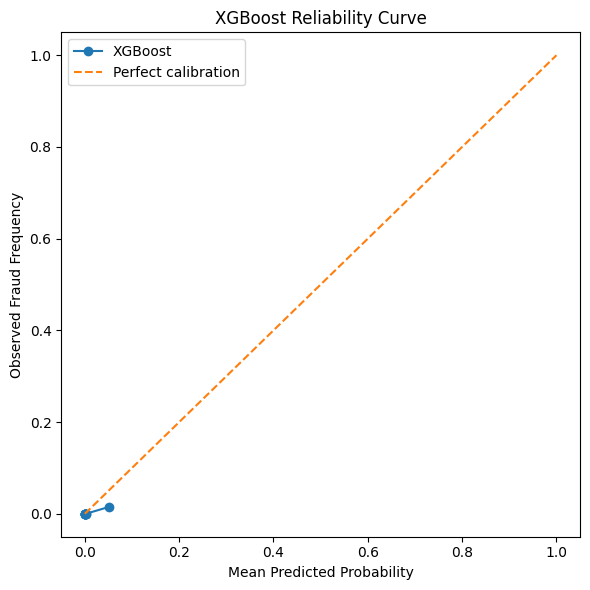

In [ ]:
# Step 13B — Reliability curve

from sklearn.calibration import calibration_curve

prob_true, prob_pred = calibration_curve(
    y_val,
    primary_val_prob,
    n_bins=10,
    strategy="quantile"
)

plt.figure(figsize=(6, 6))

plt.plot(
    prob_pred,
    prob_true,
    marker="o",
    label="XGBoost"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Perfect calibration"
)

plt.xlabel("Mean Predicted Probability")
plt.ylabel("Observed Fraud Frequency")
plt.title("XGBoost Reliability Curve")
plt.legend()

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "xgboost_reliability_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


#Because fraud is extremely rare, don't be surprised if the calibration curve looks unusual. '
#'That's normal for heavily imbalanced data.

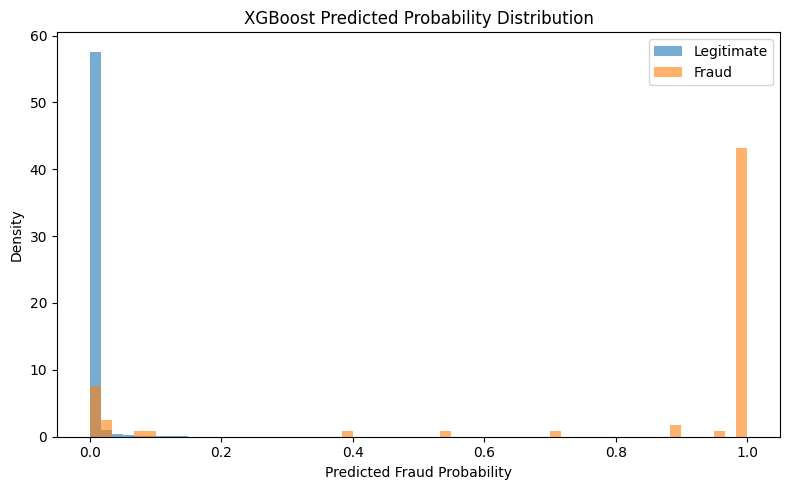

In [90]:
# Step 13C — Inspect probability distribution by class

plt.figure(figsize=(8, 5))

plt.hist(
    primary_val_prob[y_val.values == 0],
    bins=60,
    alpha=0.6,
    density=True,
    label="Legitimate"
)

plt.hist(
    primary_val_prob[y_val.values == 1],
    bins=60,
    alpha=0.6,
    density=True,
    label="Fraud"
)

plt.xlabel("Predicted Fraud Probability")
plt.ylabel("Density")
plt.title("XGBoost Predicted Probability Distribution")
plt.legend()

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "xgboost_probability_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [91]:
# Step 13D — Save calibration summary

calibration_summary = pd.DataFrame({
    "Model": ["XGBoost"],
    "Brier_Score": [brier],
    "ECE_10_Bins": [xgb_val_ece],
    "Validation_ROC_AUC": [
        xgb_optimized_results["ROC_AUC"]
    ],
    "Validation_PR_AUC": [
        xgb_optimized_results["PR_AUC"]
    ]
})

print(calibration_summary)

calibration_summary.to_csv(
    RESULTS_DIR / "xgboost_calibration_summary.csv",
    index=False
)

     Model  Brier_Score  ECE_10_Bins  Validation_ROC_AUC  Validation_PR_AUC
0  XGBoost      0.00129      0.00434            0.962666           0.761911


These results are useful, but I would not conclude “the model is perfectly calibrated” from the low Brier score and ECE alone.
Your numbers are:
- Brier score: 0.001290
- ECE: 0.004340
- ROC-AUC: 0.9627
- PR-AUC: 0.7619
The low Brier score looks good, but remember the fraud prevalence is only about 0.17%. On such an imbalanced dataset, calibration metrics can look deceptively small because almost every observation is legitimate.
Your reliability curve shows the same issue: most quantile bins are concentrated very close to zero. There simply are not enough fraud cases to populate the full probability range evenly. So the curve is not evidence of perfect calibration; rather, it shows that standard reliability diagrams are difficult to interpret under this level of imbalance.
The probability-distribution plot is more informative. It shows strong separation: most legitimate transactions have probabilities near 0, while many fraud transactions are concentrated near 1. That is consistent with the strong PR-AUC and recall we already observed.
The important methodological point is this:
We do not actually need perfectly calibrated probabilities for split conformal prediction.

The conformal guarantee comes from using a separate calibration sample and exchangeability, not from the raw XGBoost probabilities being perfectly calibrated. So I do not recommend adding Platt scaling or isotonic calibration right now. Doing so would require another clean held-out calibration subset, and our current calibration set contains only 47 fraud cases. Splitting it again would weaken the conformal stage.
For the paper, a careful interpretation would be:
“The XGBoost model demonstrated a low Brier score and low aggregate expected calibration error on the validation set. However, because of the extreme class imbalance, these measures were interpreted cautiously. Reliability-curve inspection showed that most observations were concentrated in low-probability regions, motivating the use of conformal prediction as a separate uncertainty-quantification mechanism rather than relying solely on raw probability calibration.”

That is much stronger scientifically than claiming the probabilities are perfectly calibrated.

In [ ]:
#=====================================================================================================
# Step 14 — SHAP explainability
#=====================================================================================================
# Now we move to the first major trustworthy-AI component: explaining why XGBoost flags transactions.

import shap

# Use our selected primary model
primary_model = xgb_model

# Sample the validation set to keep SHAP computation manageable
X_shap = X_val.sample(
    n=min(3000, len(X_val)),
    random_state=RANDOM_STATE
)

print("SHAP sample shape:", X_shap.shape)

SHAP sample shape: (3000, 30)


In [ ]:
# Then create the explainer:

explainer = shap.TreeExplainer(primary_model)

shap_values = explainer.shap_values(X_shap)

print("SHAP values generated.")
print("SHAP shape:", np.array(shap_values).shape)

# For recent SHAP versions, you may instead get an Explanation object. If the above works, continue.

SHAP values generated.
SHAP shape: (3000, 30)


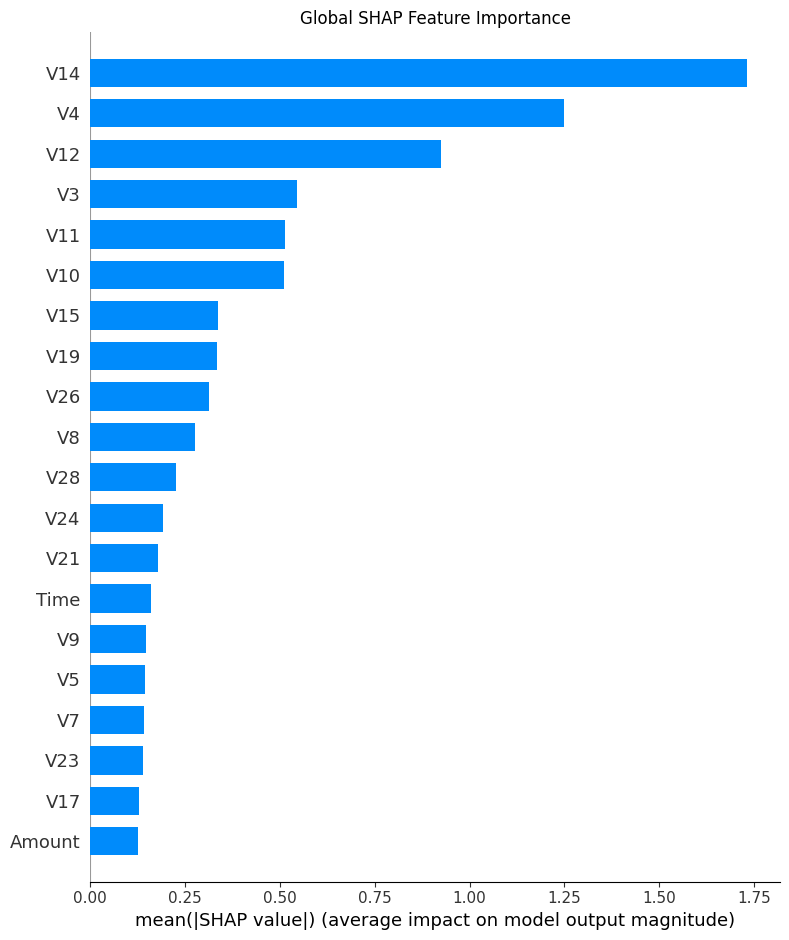

In [94]:
# Global feature importance

plt.figure()

shap.summary_plot(
    shap_values,
    X_shap,
    plot_type="bar",
    show=False
)

plt.title("Global SHAP Feature Importance")

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "shap_global_feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

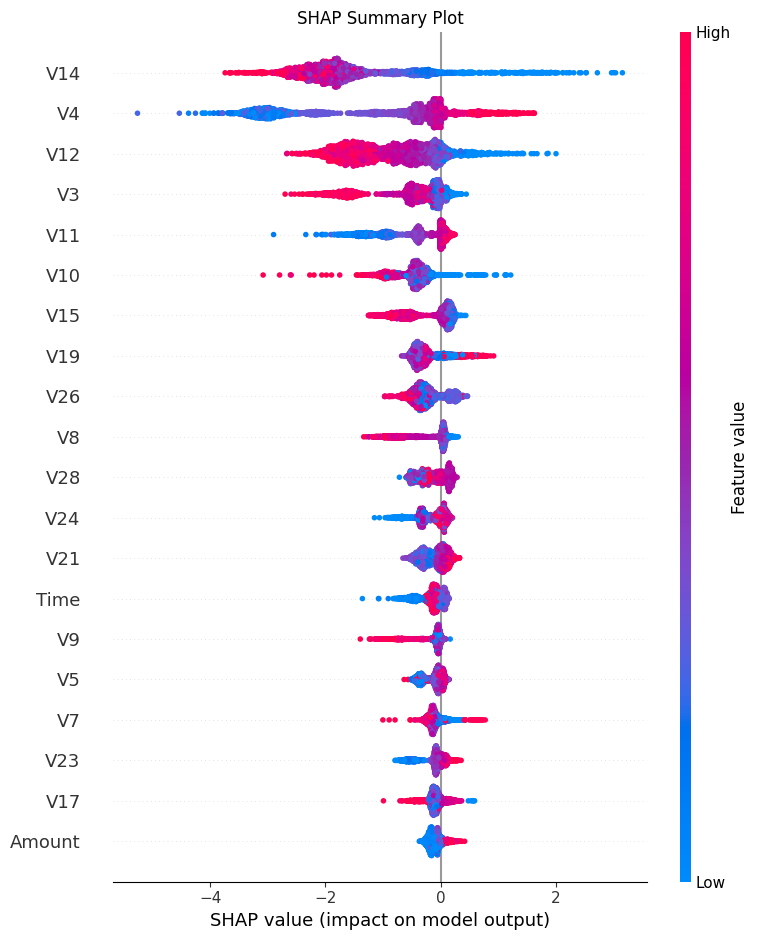

In [95]:
# Then make the richer SHAP summary plot:

plt.figure()

shap.summary_plot(
    shap_values,
    X_shap,
    show=False
)

plt.title("SHAP Summary Plot")

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "shap_summary_plot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

These SHAP results look very good and, importantly, they are consistent with what we saw earlier in the correlation analysis. Step 14 is successful.
Your SHAP matrix has the expected shape:
(3000, 30)

That means 3,000 validation transactions × 30 input features were explained.
What the global SHAP results tell us
The most influential features for the XGBoost model are approximately:
1. V14
2. V4
3. V12
4. V3
5. V11
6. V10
7. V15
8. V19
9. V26
10. V8
V14 is clearly dominant, with substantially greater mean absolute SHAP impact than the other variables.
That does not mean V14 has a known business interpretation. Because V1–V28 are anonymized PCA-derived variables, our paper must say things such as:
V14 exhibited the greatest global contribution to model predictions.

We must not say:
V14 represents transaction location/customer behavior/etc.

because the dataset does not tell us that.
The summary plot is even more informative
Remember:
- SHAP > 0 pushes the XGBoost output toward fraud
- SHAP < 0 pushes it toward legitimate
- red = higher feature value
- blue = lower feature value
Your graph shows some particularly clear patterns.
V14
For V14, low values (blue) frequently appear on the positive SHAP side, while higher values (red) tend to be strongly negative.
So:
Lower values of V14 generally push the model toward fraud predictions, while higher V14 values tend to reduce the fraud score.

This is one of the clearest relationships in your model.
V4
V4 behaves almost oppositely.
High V4 values (red) occur mainly on the positive side.
Therefore:
Higher V4 values tend to increase the predicted fraud score.

V12
Like V14:
- higher V12 → mostly negative contribution
- lower V12 → more positive contribution
So lower V12 values tend to push the model toward fraud.
V11
Higher V11 values are predominantly associated with positive SHAP contributions.
So:
Higher V11 tends to increase the model's fraud prediction.

V10
Lower V10 values are more commonly associated with positive fraud contributions, while higher values tend toward negative contributions.
This is useful because our earlier simple correlation analysis also found variables such as V14, V12, V10, V4, and V11 associated with the target. SHAP now gives us a much stronger model-specific explanation.
An important distinction for the paper
The first plot answers:
Which features matter most overall?

The second answers:
In which direction do different feature values influence predictions?

And shortly we will answer the third question:
Why did the model classify one particular transaction as fraud?

That gives us global + directional + local explainability, which is much stronger than including just a feature-importance chart.

In [96]:
# Step 15 — Local SHAP explanation of a real fraud case
# We should still not use the final test set.
# We'll select a real fraud case from the validation set, preferably one that XGBoost correctly identifies with high confidence.


# Find fraud transactions in the validation set

fraud_mask = y_val == 1

X_val_fraud = X_val.loc[fraud_mask]
y_val_fraud = y_val.loc[fraud_mask]

fraud_probabilities = primary_model.predict_proba(
    X_val_fraud
)[:, 1]

print("Number of validation fraud cases:", len(X_val_fraud))

print(
    "Highest fraud probability:",
    fraud_probabilities.max()
)

Number of validation fraud cases: 71
Highest fraud probability: 0.99986744


In [ ]:
# Now select the highest-confidence correctly identified fraud case:

highest_fraud_position = np.argmax(
    fraud_probabilities
)

selected_fraud_index = (
    X_val_fraud.index[
        highest_fraud_position
    ]
)

selected_case = X_val.loc[
    [selected_fraud_index]
]

selected_probability = (
    primary_model
    .predict_proba(selected_case)[0, 1]
)

print("Selected validation index:", selected_fraud_index)
print("True class:", y_val.loc[selected_fraud_index])
print(
    "Predicted fraud probability:",
    selected_probability
)


#We would expect: True class: 1   and likely a high fraud score.

Selected validation index: 42755
True class: 1
Predicted fraud probability: 0.99986744


In [98]:
# Step 15B — Calculate SHAP values for this transaction

selected_shap_values = explainer.shap_values(
    selected_case
)

selected_shap_values = np.asarray(
    selected_shap_values
).reshape(-1)

print(
    "Number of SHAP values:",
    len(selected_shap_values)
)

Number of SHAP values: 30


In [ ]:
# Step 15C — Create a local explanation table

local_explanation = pd.DataFrame({
    "Feature": selected_case.columns,
    "Feature_Value": selected_case.iloc[0].values,
    "SHAP_Value": selected_shap_values
})

local_explanation["Absolute_SHAP"] = (
    local_explanation[
        "SHAP_Value"
    ].abs()
)

local_explanation = (
    local_explanation
    .sort_values(
        "Absolute_SHAP",
        ascending=False
    )
)

print(
    local_explanation.head(10)
)

# This will tell us exactly which variables drove this particular fraud decision.

   Feature  Feature_Value  SHAP_Value  Absolute_SHAP
14     V14      -9.887214    3.057517       3.057517
12     V12     -11.960866    1.993926       1.993926
10     V10     -12.695947    1.159718       1.159718
4       V4       8.698610    0.792067       0.792067
16     V16     -11.350244    0.617026       0.617026
17     V17     -21.710188    0.557421       0.557421
8       V8       8.218191   -0.393929       0.393929
7       V7     -14.019291    0.390631       0.390631
3       V3     -13.455636    0.289716       0.289716
21     V21       2.549628    0.242635       0.242635


In [100]:
# SAVING IT

local_explanation.to_csv(
    RESULTS_DIR /
    "shap_local_fraud_explanation.csv",
    index=False
)

print(
    "Saved: shap_local_fraud_explanation.csv"
)

Saved: shap_local_fraud_explanation.csv


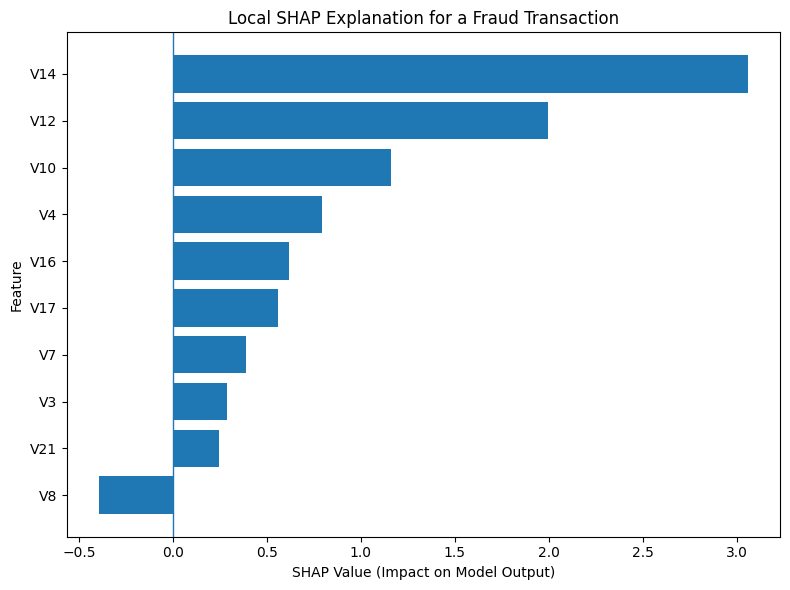

In [ ]:
# Step 15D — Plot the top local SHAP contributions

top_local = (
    local_explanation
    .head(10)
    .sort_values("SHAP_Value")
)

plt.figure(figsize=(8, 6))

plt.barh(
    top_local["Feature"],
    top_local["SHAP_Value"]
)

plt.axvline(
    0,
    linewidth=1
)

plt.xlabel(
    "SHAP Value (Impact on Model Output)"
)

plt.ylabel("Feature")

plt.title(
    "Local SHAP Explanation for a Fraud Transaction"
)

plt.tight_layout()

plt.savefig(
    FIGURES_DIR /
    "shap_local_fraud_explanation.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


#A positive bar means: => this feature pushed this particular transaction toward fraud.

#A negative bar means: => this feature pushed it toward legitimate.

In [ ]:
# Also save the global feature importance numerically
# Since the global plot is important for the paper, save the underlying values too:

global_shap_importance = pd.DataFrame({
    "Feature": X_shap.columns,
    "Mean_Absolute_SHAP": np.abs(
        shap_values
    ).mean(axis=0)
})

global_shap_importance = (
    global_shap_importance
    .sort_values(
        "Mean_Absolute_SHAP",
        ascending=False
    )
)

global_shap_importance.to_csv(
    RESULTS_DIR /
    "shap_global_feature_importance.csv",
    index=False
)

print(global_shap_importance.head(15))

   Feature  Mean_Absolute_SHAP
14     V14            1.731811
4       V4            1.249166
12     V12            0.923891
3       V3            0.544320
11     V11            0.513009
10     V10            0.511741
15     V15            0.335828
19     V19            0.334996
26     V26            0.312487
8       V8            0.276316
28     V28            0.226310
24     V24            0.191358
21     V21            0.178336
0     Time            0.161231
9       V9            0.147448


These local SHAP results are excellent and consistent with the global explanation, so Step 15 is successful.
For the selected fraud transaction:
- True class = 1
- Predicted fraud probability = 0.999867
- The strongest positive drivers toward fraud were:
  - V14 = +3.058
  - V12 = +1.994
  - V10 = +1.160
  - V4 = +0.792
  - V16 = +0.617
  - V17 = +0.557
V8 had a negative SHAP value of about −0.394, meaning it pushed this transaction slightly toward the legitimate class, but the positive contributions from V14, V12, V10, and others were much stronger.
This is exactly the kind of local explanation we want for the paper: the model not only identifies the transaction as fraud, but we can show which anonymized variables contributed most strongly to that decision.
For the paper, a careful interpretation would be:
For an illustrative fraudulent transaction, the XGBoost model assigned a fraud probability of approximately 0.9999. Local SHAP analysis showed that V14, V12, V10, V4, V16, and V17 were the strongest positive contributors to the fraud prediction, while V8 exerted a modest negative contribution. Because the PCA-derived variables are anonymized, these results are interpreted as model-level feature contributions rather than real-world semantic risk factors.

Now we should do Step 16 — Error Analysis before conformal prediction.

In [ ]:
# Step 16 => Analyze model errors
# We will use the optimized threshold for the original XGBoost:


best_threshold_xgb


np.float32(0.8904976)

In [104]:
# 16A — Build a validation decision table

validation_analysis = X_val.copy()

validation_analysis["True_Class"] = y_val.values
validation_analysis["Fraud_Probability"] = xgb_val_prob

validation_analysis["Predicted_Class"] = (
    validation_analysis["Fraud_Probability"]
    >= best_threshold_xgb
).astype(int)

print(validation_analysis.head())

            Time         V1        V2         V3        V4        V5  \
135772   81627.0   0.264001 -1.241391   0.225003  1.435049 -0.737481   
85241    60827.0  -1.182727  1.677945   0.933585 -0.107050 -0.202403   
19496    30383.0 -11.840669  6.587560 -12.243821  2.141505 -6.901092   
254736  157349.0  -1.757812  1.268514  -0.243560  0.834001  0.370026   
39191    39802.0   1.261798  0.049346   0.470507  0.798510 -0.413628   

              V6        V7        V8        V9  ...       V23       V24  \
135772  0.222482  0.327214  0.067913 -0.158827  ... -0.340856  0.019327   
85241  -0.945336  0.799868 -0.147686  0.254896  ...  0.007280  0.318081   
19496  -1.937260 -4.826890  7.937533  0.227245  ... -0.553772 -0.738400   
254736  0.082730  0.201648  0.651833  0.323763  ... -0.144330  0.699116   
39191  -0.384673 -0.113820 -0.104769  0.571608  ... -0.133295  0.111973   

             V25       V26       V27       V28  Amount  True_Class  \
135772  0.140895 -0.513671 -0.038683  0.095439

In [105]:
# 16B — Label TP, TN, FP, FN

def classify_outcome(row):
    if row["True_Class"] == 1 and row["Predicted_Class"] == 1:
        return "TP"
    elif row["True_Class"] == 0 and row["Predicted_Class"] == 0:
        return "TN"
    elif row["True_Class"] == 0 and row["Predicted_Class"] == 1:
        return "FP"
    else:
        return "FN"

validation_analysis["Outcome"] = (
    validation_analysis.apply(
        classify_outcome,
        axis=1
    )
)

print(
    validation_analysis["Outcome"]
    .value_counts()
)

Outcome
TN    42482
TP       54
FN       17
FP        6
Name: count, dtype: int64


In [ ]:
#  16C — Inspect false positives

false_positives = (
    validation_analysis[
        validation_analysis["Outcome"] == "FP"
    ]
    .sort_values(
        "Fraud_Probability",
        ascending=False
    )
)

print("Number of false positives:", len(false_positives))

print(
    false_positives[
        [
            "Fraud_Probability",
            "True_Class",
            "Predicted_Class"
        ]
    ]
)

# These are legitimate transactions that the model incorrectly flagged as fraud.

Number of false positives: 6
        Fraud_Probability  True_Class  Predicted_Class
154279           0.999703           0                1
149205           0.999220           0                1
10414            0.998803           0                1
43237            0.998569           0                1
8586             0.934264           0                1
273745           0.916428           0                1


In [ ]:
# 16D — Inspect false negatives

false_negatives = (
    validation_analysis[
        validation_analysis["Outcome"] == "FN"
    ]
    .sort_values(
        "Fraud_Probability",
        ascending=True
    )
)

print("Number of false negatives:", len(false_negatives))

print(
    false_negatives[
        [
            "Fraud_Probability",
            "True_Class",
            "Predicted_Class"
        ]
    ]
)


# These are actual fraud cases that the model missed.
# For fraud detection, these are especially important.

Number of false negatives: 17
        Fraud_Probability  True_Class  Predicted_Class
100242           0.000243           1                0
130779           0.000308           1                0
27256            0.000690           1                0
244437           0.002097           1                0
175384           0.002529           1                0
107830           0.003550           1                0
273358           0.009319           1                0
253455           0.011737           1                0
58516            0.012764           1                0
101128           0.017659           1                0
67805            0.021873           1                0
274961           0.026050           1                0
231118           0.078646           1                0
212341           0.092158           1                0
93159            0.383918           1                0
14285            0.546977           1                0
250968           0.713855          

In [ ]:
# 16E — Looking at the most dangerous false negatives


print(
    false_negatives[
        [
            "Fraud_Probability",
            "V14",
            "V12",
            "V10",
            "V4",
            "V11",
            "Amount"
        ]
    ]
    .head(10)
)

# This lets us inspect fraud cases that received very low fraud probabilities.

        Fraud_Probability       V14       V12       V10        V4       V11  \
100242           0.000243  0.217470 -0.005423 -1.769060 -1.313275 -0.651414   
130779           0.000308  0.521484  0.933216  0.269562  3.128243  1.293418   
27256            0.000690  0.038372  1.237773  0.644550  2.520863  1.120505   
244437           0.002097 -0.142099  0.435542  1.280167  2.620282  0.470865   
175384           0.002529  1.075248 -0.220719 -1.531608  1.309580 -1.394328   
107830           0.003550  1.027584 -0.868686  0.324239  2.891388 -1.273935   
273358           0.009319  0.984344 -0.050468  2.688670  6.950983 -1.475145   
253455           0.011737  0.141332 -0.973764  1.081514  2.882138 -1.514205   
58516            0.012764 -0.994581 -0.818804 -0.552903  1.209196 -0.668359   
101128           0.017659 -0.431690 -0.238383  0.517568  0.053740 -1.356558   

         Amount  
100242   549.06  
130779     0.20  
27256      1.52  
244437     2.47  
175384  2125.87  
107830     0.76  
2733

In [ ]:
# 16F — Look at high-confidence false positives

print(
    false_positives[
        [
            "Fraud_Probability",
            "V14",
            "V12",
            "V10",
            "V4",
            "V11",
            "Amount"
        ]
    ]
    .head(10)
)

# These are especially interesting because the model was confident but wrong.

        Fraud_Probability        V14        V12        V10         V4  \
154279           0.999703  -4.164920  -6.456384  -3.893139   2.806816   
149205           0.999220  -4.928340  -6.793518  -5.142403   1.698102   
10414            0.998803 -13.780377 -15.144988 -11.208723   5.565240   
43237            0.998569  -3.901461  -4.858860  -8.090151   6.590421   
8586             0.934264  -5.429772  -4.623637  -2.684483   3.445290   
273745           0.916428  -6.795942  -9.189418 -12.005487  15.304184   

              V11    Amount  
154279   4.059624      1.52  
149205   3.214640      1.00  
10414   10.002190      1.00  
43237    3.599292      1.00  
8586     2.535746      1.00  
273745   6.853897  25691.16  


In [110]:
# 16G — Save error cases

false_positives.to_csv(
    RESULTS_DIR / "xgboost_false_positives.csv",
    index=False
)

false_negatives.to_csv(
    RESULTS_DIR / "xgboost_false_negatives.csv",
    index=False
)

print("Error-analysis files saved.")

Error-analysis files saved.


In [111]:
# 16H — Probability summary by outcome

outcome_probability_summary = (
    validation_analysis
    .groupby("Outcome")["Fraud_Probability"]
    .agg(
        ["count", "mean", "median", "min", "max"]
    )
)

print(outcome_probability_summary)

         count      mean    median       min       max
Outcome                                               
FN          17  0.113198  0.012764  0.000243  0.713855
FP           6  0.974498  0.998686  0.916428  0.999703
TN       42482  0.004572  0.000547  0.000012  0.882132
TP          54  0.994008  0.999483  0.890498  0.999867


In [112]:
# Save it:

outcome_probability_summary.to_csv(
    RESULTS_DIR /
    "xgboost_error_probability_summary.csv"
)

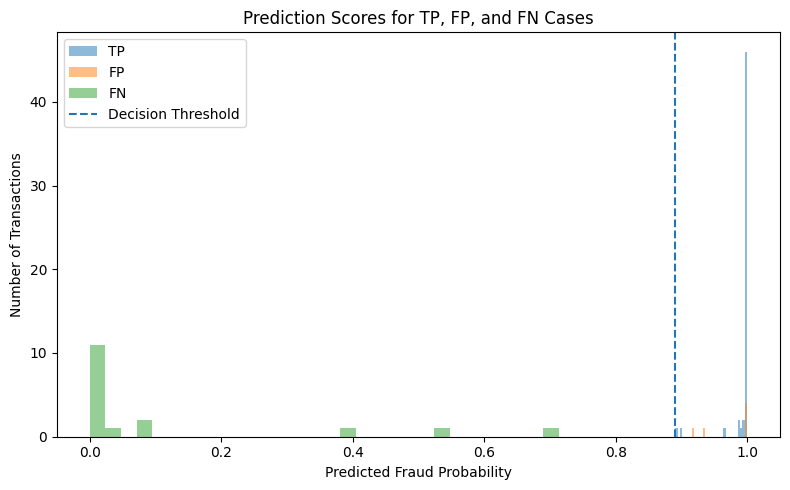

In [113]:
# 16I — Plot probability distributions by outcome

plt.figure(figsize=(8, 5))

for outcome in ["TP", "FP", "FN"]:
    values = validation_analysis.loc[
        validation_analysis["Outcome"] == outcome,
        "Fraud_Probability"
    ]

    if len(values) > 0:
        plt.hist(
            values,
            bins=30,
            alpha=0.5,
            label=outcome
        )

plt.axvline(
    best_threshold_xgb,
    linestyle="--",
    label="Decision Threshold"
)

plt.xlabel("Predicted Fraud Probability")
plt.ylabel("Number of Transactions")
plt.title("Prediction Scores for TP, FP, and FN Cases")
plt.legend()

plt.tight_layout()

plt.savefig(
    FIGURES_DIR /
    "xgboost_error_probability_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Step 16 is complete, and these results are especially useful because they show where the model fails, not just how often.
Your optimized XGBoost produced exactly what we expected:
Outcome	Count
True negatives	42,482
True positives	54
False negatives	17
False positives	6


The error patterns are quite revealing. The false positives are extremely confident: their mean fraud probability is about 0.9745, and four of the six are above 0.998. Their feature patterns also resemble the fraud-driving patterns from SHAP: strongly negative V14, V12, V10 and positive V4/V11. So these are not borderline cases—the model genuinely sees them as fraud-like.
The false negatives are the opposite. Their median fraud probability is only 0.0128, and several actual fraud cases receive probabilities below 0.01. This tells us an important limitation:
Some model errors are high-confidence errors.

That matters for our trustworthy-AI argument. Conformal prediction is not a magic mechanism that will necessarily identify every wrong prediction as uncertain. Its guarantee is statistical coverage over future observations under its assumptions, not “every mistake gets sent to human review.”
That nuance will make the paper much stronger.

Step 17 — Conformal Prediction
Because this dataset is extremely imbalanced, I recommend we slightly improve the original plan.
Instead of relying only on ordinary marginal split conformal prediction, we should use class-conditional (Mondrian) split conformal prediction as our main approach.
Why?
Your calibration set contains:
- 28,325 legitimate transactions
- only 47 fraud cases
If we calculate one single conformal threshold across all calibration observations, the legitimate class completely dominates the calibration distribution. We could achieve good overall coverage while still protecting fraud cases poorly.
Class-conditional conformal prediction calculates a separate uncertainty threshold for:
- legitimate transactions
- fraudulent transactions
That is much more appropriate for our fraud-detection research.
Our method will still be simple:
\[
s_i = 1-\hat p(y_i\mid x_i)
\]
where the nonconformity score is high when the model gives low probability to the true class.

In [114]:
# Step 17A — Obtain probabilities on the calibration set
#Note: until now we have not used X_cal to tune the model. That is exactly what we want.


# Probability predictions on the untouched conformal calibration set

cal_prob_fraud = primary_model.predict_proba(
    X_cal
)[:, 1]

cal_prob_normal = 1 - cal_prob_fraud

print("Calibration observations:", len(X_cal))
print("Calibration fraud cases:", int(y_cal.sum()))
print(
    "Calibration legitimate cases:",
    int((y_cal == 0).sum())
)

print(
    "\nFraud probability range:",
    cal_prob_fraud.min(),
    cal_prob_fraud.max()
)

Calibration observations: 28372
Calibration fraud cases: 47
Calibration legitimate cases: 28325

Fraud probability range: 1.1461857e-05 0.9998443


In [115]:
# Step 17B — Calculate nonconformity scores
# For a legitimate calibration transaction:

#score = 1 - P(Normal)

#   which is equivalent to its fraud probability.
#   For a fraudulent calibration transaction:
#   score = 1 - P(Fraud)


y_cal_array = y_cal.to_numpy()

cal_scores = np.where(
    y_cal_array == 1,
    1 - cal_prob_fraud,
    1 - cal_prob_normal
)

print("Calibration score range:")
print("Minimum:", cal_scores.min())
print("Maximum:", cal_scores.max())



Calibration score range:
Minimum: 1.1444092e-05
Maximum: 0.99989843


In [116]:
# Now separate them by true class:

normal_cal_scores = cal_scores[
    y_cal_array == 0
]

fraud_cal_scores = cal_scores[
    y_cal_array == 1
]

print(
    "Number of normal calibration scores:",
    len(normal_cal_scores)
)

print(
    "Number of fraud calibration scores:",
    len(fraud_cal_scores)
)

Number of normal calibration scores: 28325
Number of fraud calibration scores: 47


In [ ]:
# Step 17C — Define the finite-sample conformal quantile correctly

#This detail matters.
#Do not simply use: =>   np.quantile(scores, 0.90)


#We want the finite-sample conformal correction.



def conformal_quantile(scores, alpha):
    scores = np.asarray(scores)

    n = len(scores)

    level = np.ceil(
        (n + 1) * (1 - alpha)
    ) / n

    level = min(level, 1.0)

    return np.quantile(
        scores,
        level,
        method="higher"
    )

# This is a more defensible implementation for the paper.

In [ ]:
# Step 17D — Start with α = 0.10
#This corresponds to nominal 90% class-conditional coverage.

alpha = 0.10

q_normal = conformal_quantile(
    normal_cal_scores,
    alpha
)

q_fraud = conformal_quantile(
    fraud_cal_scores,
    alpha
)

print("Alpha:", alpha)
print("Target coverage:", 1 - alpha)

print(
    "Normal-class conformal threshold:",
    q_normal
)

print(
    "Fraud-class conformal threshold:",
    q_fraud
)


# The two values will probably be quite different.
# That difference itself is interesting because it reflects the asymmetric difficulty of the two classes.

Alpha: 0.1
Target coverage: 0.9
Normal-class conformal threshold: 0.005513966
Fraud-class conformal threshold: 0.996914


Step 17E — Generate prediction sets on the test set
This is the first time we will use X_test for the conformal experiment.

Important distinction:
We will not tune anything on the test set.
We're only applying the already-fixed model and calibration thresholds.

In [119]:
test_prob_fraud = primary_model.predict_proba(
    X_test
)[:, 1]

test_prob_normal = 1 - test_prob_fraud

Now construct prediction sets.
A class is included if its candidate nonconformity score does not exceed its class-specific calibration threshold.

In [120]:
include_normal = (
    (1 - test_prob_normal)
    <= q_normal
)

include_fraud = (
    (1 - test_prob_fraud)
    <= q_fraud
)

Step 17F — Inspect possible prediction sets

In [121]:
prediction_sets = []

for normal_in, fraud_in in zip(
    include_normal,
    include_fraud
):
    current_set = []

    if normal_in:
        current_set.append(0)

    if fraud_in:
        current_set.append(1)

    prediction_sets.append(
        tuple(current_set)
    )

Now count the different sets:

In [ ]:
from collections import Counter

set_counts = Counter(
    prediction_sets
)

print("Conformal prediction-set counts:")

for pred_set, count in set_counts.items():
    print(pred_set, ":", count)


# Do not worry if empty sets occur. 
# They are valid in this type of conformal construction and should be treated as requiring human review.

Conformal prediction-set counts:
(1,) : 4193
(0,) : 35971
(0, 1) : 2396


In [ ]:
# Step 17G — Calculate overall coverage

y_test_array = y_test.to_numpy()

covered = np.array([
    true_label in pred_set
    for true_label, pred_set
    in zip(
        y_test_array,
        prediction_sets
    )
])

overall_coverage = covered.mean()

print(
    "Overall empirical coverage:",
    overall_coverage
)


# For α = 0.10 we hope to see something around or above: 0.90
# but remember finite test variation is possible.

Overall empirical coverage: 0.9030075187969925


In [ ]:
# Step 17H — Calculate coverage separately by class
# This is particularly important for this paper.


normal_test_mask = (
    y_test_array == 0
)

fraud_test_mask = (
    y_test_array == 1
)

normal_coverage = covered[
    normal_test_mask
].mean()

fraud_coverage = covered[
    fraud_test_mask
].mean()

print(
    "Normal-class coverage:",
    normal_coverage
)

print(
    "Fraud-class coverage:",
    fraud_coverage
)

#This is why we chose class-conditional conformal prediction.
#The fraud-class coverage is much more meaningful than overall coverage alone.

Normal-class coverage: 0.9029160488597049
Fraud-class coverage: 0.9577464788732394


In [ ]:
# Step 17I — Average prediction-set size

set_sizes = np.array([
    len(pred_set)
    for pred_set in prediction_sets
])

average_set_size = (
    set_sizes.mean()
)

print(
    "Average prediction-set size:",
    average_set_size
)


#Interpretation:
#- close to 1 → mostly confident singleton predictions
#- approaching 2 → lots of uncertainty

Average prediction-set size: 1.056296992481203


Step 17J — Human-review decisions

Using this rule:

{0}     → Confident Normal

{1}     → Confident Fraud

{0,1}   → Human Review

{}      → Human Review

In [127]:
def interpret_prediction_set(
    pred_set
):
    if pred_set == (0,):
        return "Confident Normal"

    elif pred_set == (1,):
        return "Confident Fraud"

    elif pred_set == (0, 1):
        return "Human Review"

    else:
        return "Human Review"

In [128]:
decisions = [
    interpret_prediction_set(s)
    for s in prediction_sets
]

decision_counts = pd.Series(
    decisions
).value_counts()

print(decision_counts)

Confident Normal    35971
Confident Fraud      4193
Human Review         2396
Name: count, dtype: int64


In [129]:
# Step 17K — Calculate human-review rate

human_review_mask = np.array([
    d == "Human Review"
    for d in decisions
])

human_review_rate = (
    human_review_mask.mean()
)

print(
    "Human-review rate:",
    human_review_rate
)

Human-review rate: 0.056296992481203005


In [130]:
# Step 17L — Accuracy among confident decisions
# This is one of our strongest research metrics.

confident_mask = (
    ~human_review_mask
)

confident_predictions = np.array([
    s[0] if len(s) == 1 else -1
    for s in prediction_sets
])

if confident_mask.sum() > 0:
    confident_accuracy = (
        confident_predictions[
            confident_mask
        ]
        ==
        y_test_array[
            confident_mask
        ]
    ).mean()
else:
    confident_accuracy = np.nan

print(
    "Number of confident decisions:",
    confident_mask.sum()
)

print(
    "Confident accuracy:",
    confident_accuracy
)

Number of confident decisions: 40164
Confident accuracy: 0.8972213922916045


These results are mathematically valid, but they reveal an important problem with the class-conditional conformal setup on this dataset. We should not proceed as though this is already a good human-review system.
Your coverage results look excellent:
- Overall coverage: 90.30%
- Normal-class coverage: 90.29%
- Fraud-class coverage: 95.77%
- Target coverage: 90%
So the class-conditional conformal method is doing what it is supposed to do in terms of coverage.
But the operational behavior is poor.
You obtained:
Confident Normal    35,971
Confident Fraud      4,193
Human Review         2,396

There are only 71 actual fraud cases in the entire test set.
So having 4,193 “Confident Fraud” predictions is clearly far too aggressive.
That is why your:
Confident accuracy = 89.72%

is surprisingly low.
For comparison, because the dataset is overwhelmingly legitimate, even predicting everything as legitimate would exceed 99% accuracy. Therefore, 89.7% accuracy among supposedly confident predictions is not acceptable for our trustworthy decision layer.
Why this happened
Look at the two conformal thresholds:
Normal threshold = 0.005514
Fraud threshold  = 0.996914

The fraud threshold is enormous.
For candidate class Fraud, we include fraud when:
1 - P(Fraud) <= 0.996914

which is equivalent to approximately:
P(Fraud) >= 0.003086

That is an extremely low bar.
So practically, almost any transaction with fraud probability above 0.3% can have the fraud class included.
At the same time, normal is included only when roughly:
P(Fraud) <= 0.005514

Therefore, many transactions with probabilities above about 0.0055 end up as:
{Fraud}

even though many are actually legitimate.
That's why you get thousands of “Confident Fraud” predictions.
Why is q_fraud so high?
This connects directly to our earlier error analysis.
We discovered that some actual fraud cases receive extremely low fraud probabilities:
0.000243
0.000308
0.000690
0.002097
...

For one of those fraud transactions:
P(Fraud) = 0.000243

the fraud nonconformity score is:
1 - 0.000243 ≈ 0.999757

Those huge scores push the fraud conformal threshold close to 1.0.
And remember, our conformal calibration set contains only:
47 fraud observations

So a handful of hard fraud examples substantially influence the threshold.
This is a very meaningful research finding.
We should NOT hide this
In fact, this can improve the paper.
We can truthfully say:
Class-conditional conformal prediction achieved the intended class-wise coverage, including 95.8% empirical coverage for fraudulent transactions at nominal 90% coverage. However, the severe class imbalance and limited number of fraud calibration examples resulted in a very permissive fraud-class threshold, producing an impractically large number of singleton fraud prediction sets. This demonstrates that coverage guarantees alone do not imply operational usefulness.

That is a strong and sophisticated observation.
What we should do next
I recommend we keep this class-conditional experiment as an important comparison, but do not use it as our final human-review mechanism.
Now we should test ordinary marginal split conformal prediction.
Why?
It uses one calibration threshold across all transactions. This will probably produce behavior more like:
very low fraud probability
        ↓
{Normal}

intermediate probability
        ↓
empty or {Normal, Fraud}
        ↓
Human Review

very high fraud probability
        ↓
{Fraud}

That is much closer to the decision-support framework we originally intended.
The trade-off is that marginal conformal prediction guarantees overall coverage, not equal coverage separately for fraud and legitimate classes.
We will explicitly report both.

In [131]:
# Step 18 — Marginal Split Conformal Prediction
# Use the cal_scores we already calculated.


alpha = 0.10

q_marginal = conformal_quantile(
    cal_scores,
    alpha
)

print("Marginal conformal threshold:", q_marginal)
print("Target coverage:", 1 - alpha)

Marginal conformal threshold: 0.00554657
Target coverage: 0.9


In [132]:
# Then apply it to the existing test probabilities:

include_normal_marginal = (
    (1 - test_prob_normal)
    <= q_marginal
)

include_fraud_marginal = (
    (1 - test_prob_fraud)
    <= q_marginal
)

In [133]:
# Now construct the sets:

prediction_sets_marginal = []

for normal_in, fraud_in in zip(
    include_normal_marginal,
    include_fraud_marginal
):
    current_set = []

    if normal_in:
        current_set.append(0)

    if fraud_in:
        current_set.append(1)

    prediction_sets_marginal.append(
        tuple(current_set)
    )

In [134]:
# Count them:

marginal_set_counts = Counter(
    prediction_sets_marginal
)

print("Marginal prediction-set counts:")

for pred_set, count in marginal_set_counts.items():
    print(pred_set, ":", count)

Marginal prediction-set counts:
() : 4125
(0,) : 38380
(1,) : 55


In [135]:
# Calculate coverage

covered_marginal = np.array([
    true_label in pred_set
    for true_label, pred_set
    in zip(
        y_test_array,
        prediction_sets_marginal
    )
])

marginal_overall_coverage = (
    covered_marginal.mean()
)

marginal_normal_coverage = (
    covered_marginal[
        y_test_array == 0
    ].mean()
)

marginal_fraud_coverage = (
    covered_marginal[
        y_test_array == 1
    ].mean()
)

print(
    "Overall coverage:",
    marginal_overall_coverage
)

print(
    "Normal coverage:",
    marginal_normal_coverage
)

print(
    "Fraud coverage:",
    marginal_fraud_coverage
)

Overall coverage: 0.902984022556391
Normal coverage: 0.9032220104026925
Fraud coverage: 0.7605633802816901


In [136]:
# Prediction-set size

marginal_set_sizes = np.array([
    len(s)
    for s in prediction_sets_marginal
])

print(
    "Average prediction-set size:",
    marginal_set_sizes.mean()
)

Average prediction-set size: 0.903078007518797


In [137]:
#  Human-review decisions

marginal_decisions = [
    interpret_prediction_set(s)
    for s in prediction_sets_marginal
]

print(
    pd.Series(
        marginal_decisions
    ).value_counts()
)

Confident Normal    38380
Human Review         4125
Confident Fraud        55
Name: count, dtype: int64


In [138]:
marginal_review_mask = np.array([
    decision == "Human Review"
    for decision in marginal_decisions
])

print(
    "Human-review rate:",
    marginal_review_mask.mean()
)

Human-review rate: 0.096921992481203


In [139]:
#Confident accuracy

marginal_confident_mask = (
    ~marginal_review_mask
)

marginal_confident_predictions = np.array([
    s[0] if len(s) == 1 else -1
    for s in prediction_sets_marginal
])

marginal_confident_accuracy = (
    marginal_confident_predictions[
        marginal_confident_mask
    ]
    ==
    y_test_array[
        marginal_confident_mask
    ]
).mean()

print(
    "Number of confident decisions:",
    marginal_confident_mask.sum()
)

print(
    "Confident accuracy:",
    marginal_confident_accuracy
)

Number of confident decisions: 38435
Confident accuracy: 0.9998959281904514


In [ ]:
#=================================================================
# One additional metric I want  Since fraud is our priority:
#=================================================================

confident_fraud_mask = np.array([
    s == (1,)
    for s in prediction_sets_marginal
])

print(
    "Confident fraud predictions:",
    confident_fraud_mask.sum()
)

if confident_fraud_mask.sum() > 0:
    confident_fraud_precision = (
        y_test_array[
            confident_fraud_mask
        ] == 1
    ).mean()

    print(
        "Precision among confident fraud predictions:",
        confident_fraud_precision
    )

Confident fraud predictions: 55
Precision among confident fraud predictions: 0.9818181818181818


These results are much better operationally, and they give us an important research conclusion.
The marginal conformal method achieved:
- Overall coverage: 90.30%
- Normal coverage: 90.32%
- Fraud coverage: 76.06%
- Human-review rate: 9.69%
- Confident accuracy: 99.9896%
- Confident fraud predictions: 55
- Precision among confident fraud predictions: 98.18%
So compared with the class-conditional version, this behaves far more realistically.
The prediction sets were:
- (0,) = 38,380 confident normal
- (1,) = 55 confident fraud
- () = 4,125 human review
- no (0,1) cases
That means the marginal conformal rule is effectively creating a reject region between confident normal and confident fraud. This is actually very useful for our human-in-the-loop design.
The strongest result is this:
Among all confident decisions, accuracy is about 99.99%.

And among the 55 transactions labeled confident fraud, 98.18% are actually fraud.
That is a strong result.
But there is one critical limitation:
Fraud coverage is only 76.06%, despite nominal 90% overall coverage.

This does not violate marginal conformal prediction. Marginal conformal guarantees overall coverage, not per-class coverage. Because fraud is extremely rare, the overall guarantee is dominated by legitimate transactions.
So now we have a very interesting comparison:
Method	Overall Coverage	Fraud Coverage	Human Review	Confident Accuracy
Class-conditional conformal	90.30%	95.77%	5.63%	89.72%
Marginal conformal	90.30%	76.06%	9.69%	99.99%


This is one of the strongest findings in your whole project.
The class-conditional method gives much better fraud coverage, but its operational behavior is poor because it labels thousands of legitimate transactions as confident fraud.
The marginal method gives extremely accurate confident decisions and a realistic number of confident fraud alerts, but it undercovers the rare fraud class.
That gives us a defensible research conclusion:
Coverage guarantees and operational usefulness are not the same thing.

For your paper, we should report both methods rather than hide one.
Now we should do the final sensitivity experiment across several alpha values.

Step 19 — Compare α = 0.05, 0.10, 0.20

In [141]:
def evaluate_marginal_conformal(alpha):

    q = conformal_quantile(
        cal_scores,
        alpha
    )

    include_normal = (
        (1 - test_prob_normal) <= q
    )

    include_fraud = (
        (1 - test_prob_fraud) <= q
    )

    pred_sets = []

    for n_in, f_in in zip(
        include_normal,
        include_fraud
    ):
        current = []

        if n_in:
            current.append(0)

        if f_in:
            current.append(1)

        pred_sets.append(tuple(current))

    covered = np.array([
        true_label in pred_set
        for true_label, pred_set
        in zip(
            y_test_array,
            pred_sets
        )
    ])

    sizes = np.array([
        len(s)
        for s in pred_sets
    ])

    review_mask = (
        sizes != 1
    )

    confident_mask = (
        sizes == 1
    )

    confident_predictions = np.array([
        s[0] if len(s) == 1 else -1
        for s in pred_sets
    ])

    if confident_mask.sum() > 0:
        confident_accuracy = (
            confident_predictions[
                confident_mask
            ]
            ==
            y_test_array[
                confident_mask
            ]
        ).mean()
    else:
        confident_accuracy = np.nan

    fraud_singleton_mask = np.array([
        s == (1,)
        for s in pred_sets
    ])

    if fraud_singleton_mask.sum() > 0:
        fraud_singleton_precision = (
            y_test_array[
                fraud_singleton_mask
            ] == 1
        ).mean()
    else:
        fraud_singleton_precision = np.nan

    normal_coverage = covered[
        y_test_array == 0
    ].mean()

    fraud_coverage = covered[
        y_test_array == 1
    ].mean()

    return {
        "Alpha": alpha,
        "Target_Coverage": 1 - alpha,
        "Quantile": q,
        "Overall_Coverage": covered.mean(),
        "Normal_Coverage": normal_coverage,
        "Fraud_Coverage": fraud_coverage,
        "Average_Set_Size": sizes.mean(),
        "Human_Review_Rate": review_mask.mean(),
        "Confident_Accuracy": confident_accuracy,
        "Confident_Fraud_Count": fraud_singleton_mask.sum(),
        "Confident_Fraud_Precision": fraud_singleton_precision
    }

In [142]:
alpha_values = [
    0.05,
    0.10,
    0.20
]

marginal_results = []

for alpha_value in alpha_values:

    result = evaluate_marginal_conformal(
        alpha_value
    )

    marginal_results.append(
        result
    )

marginal_results_df = pd.DataFrame(
    marginal_results
)

print(marginal_results_df)

   Alpha  Target_Coverage  Quantile  Overall_Coverage  Normal_Coverage  \
0   0.05             0.95  0.013823          0.952115         0.952364   
1   0.10             0.90  0.005547          0.902984         0.903222   
2   0.20             0.80  0.002146          0.796664         0.796794   

   Fraud_Coverage  Average_Set_Size  Human_Review_Rate  Confident_Accuracy  \
0        0.802817          0.952279           0.047721            0.999827   
1        0.760563          0.903078           0.096922            0.999896   
2        0.718310          0.796734           0.203266            0.999912   

   Confident_Fraud_Count  Confident_Fraud_Precision  
0                     60                   0.950000  
1                     55                   0.981818  
2                     52                   0.980769  


In [143]:
# SAVING IT

marginal_results_df.to_csv(
    RESULTS_DIR /
    "marginal_conformal_alpha_comparison.csv",
    index=False
)

In [144]:
# Also creatING this cleaner display:

display_columns = [
    "Alpha",
    "Target_Coverage",
    "Overall_Coverage",
    "Normal_Coverage",
    "Fraud_Coverage",
    "Human_Review_Rate",
    "Confident_Accuracy",
    "Confident_Fraud_Count",
    "Confident_Fraud_Precision"
]

print(
    marginal_results_df[
        display_columns
    ]
)

   Alpha  Target_Coverage  Overall_Coverage  Normal_Coverage  Fraud_Coverage  \
0   0.05             0.95          0.952115         0.952364        0.802817   
1   0.10             0.90          0.902984         0.903222        0.760563   
2   0.20             0.80          0.796664         0.796794        0.718310   

   Human_Review_Rate  Confident_Accuracy  Confident_Fraud_Count  \
0           0.047721            0.999827                     60   
1           0.096922            0.999896                     55   
2           0.203266            0.999912                     52   

   Confident_Fraud_Precision  
0                   0.950000  
1                   0.981818  
2                   0.980769  


These results are strong, and they show a very clear trade-off.
The marginal conformal results are:


| α | Target coverage | Overall coverage | Fraud coverage | Human review | Confident accuracy | Confident fraud precision |
|---:|---:|---:|---:|---:|---:|---:|
| 0.05 | 95% | **95.21%** | **80.28%** | **4.77%** | 99.983% | 95.00% |
| 0.10 | 90% | 90.30% | 76.06% | 9.69% | **99.990%** | **98.18%** |
| 0.20 | 80% | 79.67% | 71.83% | 20.33% | 99.991% | 98.08% |


A lower α gives a larger conformal threshold, so the reject region becomes narrower. That is why α = 0.05 gives both higher overall coverage and a lower review rate in this particular binary setup.
The result at α = 0.05 is especially interesting because it achieves the nominal overall target almost exactly:
Target = 95%
Observed = 95.21%

while only sending about 4.77% of transactions to human review.
However, there is an important methodological point: we should not now choose α based purely on which test-set row looks best, because we have already inspected these test results. For a rigorous paper, treat the three α values as a pre-specified sensitivity analysis, not hyperparameter tuning.
I recommend keeping α = 0.10 as the primary reported configuration, because that was the value we specified before running the conformal experiment. Then report α = 0.05 and 0.20 as sensitivity analyses. We can still say that α = 0.05 showed a favorable empirical trade-off, but we should not pretend it was selected before seeing the test data.
That distinction will make the paper more credible.

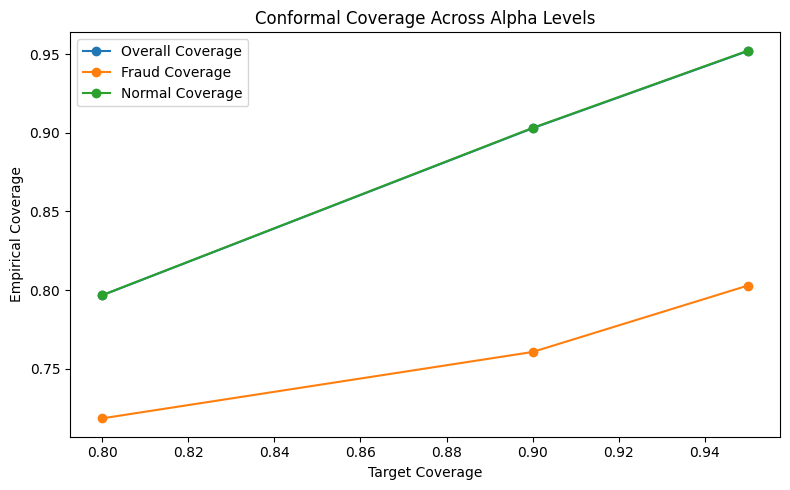

In [145]:
# Step 20 — Create the final conformal sensitivity figure

plt.figure(figsize=(8, 5))

plt.plot(
    marginal_results_df["Target_Coverage"],
    marginal_results_df["Overall_Coverage"],
    marker="o",
    label="Overall Coverage"
)

plt.plot(
    marginal_results_df["Target_Coverage"],
    marginal_results_df["Fraud_Coverage"],
    marker="o",
    label="Fraud Coverage"
)

plt.plot(
    marginal_results_df["Target_Coverage"],
    marginal_results_df["Normal_Coverage"],
    marker="o",
    label="Normal Coverage"
)

plt.xlabel("Target Coverage")
plt.ylabel("Empirical Coverage")
plt.title("Conformal Coverage Across Alpha Levels")
plt.legend()

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "conformal_coverage_sensitivity.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

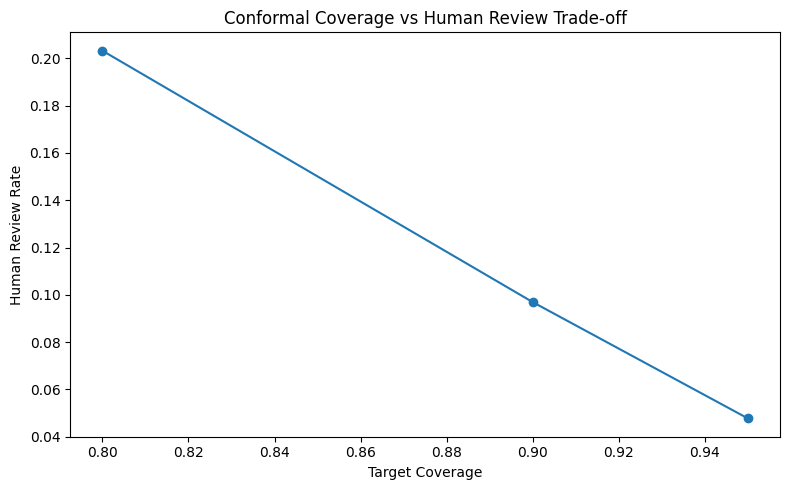

In [146]:
# Then create the review-rate trade-off:

plt.figure(figsize=(8, 5))

plt.plot(
    marginal_results_df["Target_Coverage"],
    marginal_results_df["Human_Review_Rate"],
    marker="o"
)

plt.xlabel("Target Coverage")
plt.ylabel("Human Review Rate")
plt.title("Conformal Coverage vs Human Review Trade-off")

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "conformal_review_tradeoff.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [147]:
# Now create the primary α = 0.10 decision distribution:

primary_alpha = 0.10

primary_q = conformal_quantile(
    cal_scores,
    primary_alpha
)

include_normal_primary = (
    (1 - test_prob_normal) <= primary_q
)

include_fraud_primary = (
    (1 - test_prob_fraud) <= primary_q
)

primary_sets = []

for n_in, f_in in zip(
    include_normal_primary,
    include_fraud_primary
):
    current = []

    if n_in:
        current.append(0)

    if f_in:
        current.append(1)

    primary_sets.append(tuple(current))

primary_decisions = [
    interpret_prediction_set(s)
    for s in primary_sets
]

decision_counts_primary = pd.Series(
    primary_decisions
).value_counts()

print(decision_counts_primary)

Confident Normal    38380
Human Review         4125
Confident Fraud        55
Name: count, dtype: int64


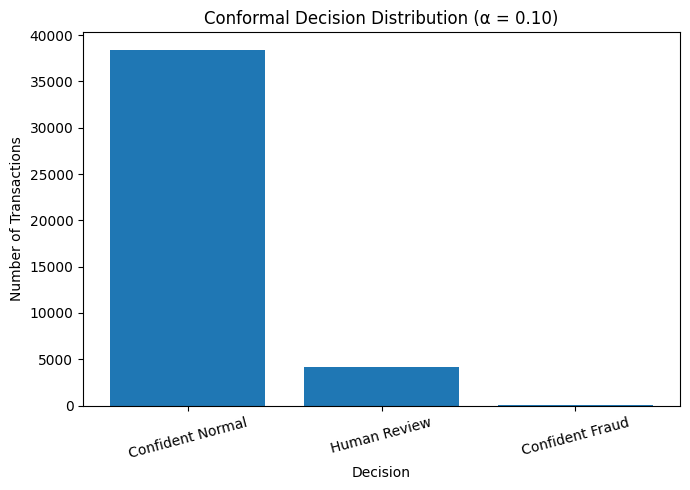

In [148]:
# Plot:

plt.figure(figsize=(7, 5))

plt.bar(
    decision_counts_primary.index,
    decision_counts_primary.values
)

plt.title(
    "Conformal Decision Distribution (α = 0.10)"
)

plt.xlabel("Decision")
plt.ylabel("Number of Transactions")

plt.xticks(rotation=15)

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "conformal_decision_distribution_alpha_010.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Step 21 — Final XGBoost classification performance on the test set

Now that all model development is finished, calculate the ordinary XGBoost test metrics using the threshold fixed earlier from the validation set:

In [149]:
xgb_test_prob = primary_model.predict_proba(
    X_test
)[:, 1]

xgb_test_pred = (
    xgb_test_prob >= best_threshold_xgb
).astype(int)

In [150]:
xgb_test_results = {
    "Accuracy": accuracy_score(
        y_test,
        xgb_test_pred
    ),
    "Precision": precision_score(
        y_test,
        xgb_test_pred,
        zero_division=0
    ),
    "Recall": recall_score(
        y_test,
        xgb_test_pred,
        zero_division=0
    ),
    "F1": f1_score(
        y_test,
        xgb_test_pred,
        zero_division=0
    ),
    "ROC_AUC": roc_auc_score(
        y_test,
        xgb_test_prob
    ),
    "PR_AUC": average_precision_score(
        y_test,
        xgb_test_prob
    )
}

print("Final XGBoost Test Results")

for metric, value in xgb_test_results.items():
    print(f"{metric}: {value:.6f}")

Final XGBoost Test Results
Accuracy: 0.999601
Precision: 0.909091
Recall: 0.845070
F1: 0.875912
ROC_AUC: 0.984725
PR_AUC: 0.886794


In [151]:
xgb_test_cm = confusion_matrix(
    y_test,
    xgb_test_pred
)

print("\nFinal Test Confusion Matrix:")
print(xgb_test_cm)


Final Test Confusion Matrix:
[[42483     6]
 [   11    60]]



Final Test Confusion Matrix:
[[42483     6]
 [   11    60]]


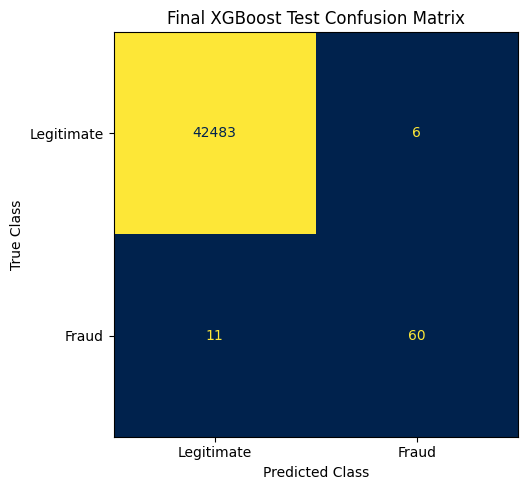

Saved: C:\Users\eliya\Pictures\Own Research\figures\xgboost_final_test_confusion_matrix.png


In [162]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Final confusion matrix
xgb_test_cm = confusion_matrix(
    y_test,
    xgb_test_pred
)

print("\nFinal Test Confusion Matrix:")
print(xgb_test_cm)

# Create confusion matrix diagram
fig, ax = plt.subplots(figsize=(6, 5))

disp = ConfusionMatrixDisplay(
    confusion_matrix=xgb_test_cm,
    display_labels=["Legitimate", "Fraud"]
)

disp.plot(
    ax=ax,
    cmap="cividis",
    values_format="d",
    colorbar=False
)

ax.set_title("Final XGBoost Test Confusion Matrix")
ax.set_xlabel("Predicted Class")
ax.set_ylabel("True Class")

plt.tight_layout()

# Save high-resolution figure for the paper
plt.savefig(
    FIGURES_DIR / "xgboost_final_test_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    "Saved:",
    FIGURES_DIR / "xgboost_final_test_confusion_matrix.png"
)

In [164]:
# SAVING IT

final_test_results_df = pd.DataFrame(
    [xgb_test_results]
)

final_test_results_df.insert(
    0,
    "Model",
    "XGBoost"
)

final_test_results_df.to_csv(
    RESULTS_DIR / "xgboost_final_test_results.csv",
    index=False
)

These final test results look very strong and internally consistent. I checked the confusion matrix against every reported metric.
Your final confusion matrix is:
                     Predicted
                 Legitimate   Fraud

Actual Legitimate    42,483       6
Actual Fraud             11      60

That means:
- TP = 60
- TN = 42,483
- FP = 6
- FN = 11
And the metrics are correct:
- Precision = 60 / (60 + 6) = 0.909091
- Recall = 60 / (60 + 11) = 0.845070
- F1 = 0.875912
- Accuracy = 0.999601
- ROC-AUC = 0.984725
- PR-AUC = 0.886794
The most important result is not the 99.96% accuracy. It is that the model detected 60 of 71 fraud cases, while creating only 6 false fraud alarms.

Your final test performance is also noticeably stronger than validation performance:

| Metric | Validation | Final Test |
|---|---:|---:|
| Precision | 0.9000 | **0.9091** |
| Recall | 0.7606 | **0.8451** |
| F1 | 0.8244 | **0.8759** |
| ROC-AUC | 0.9627 | **0.9847** |
| PR-AUC | 0.7619 | **0.8868** |


That is not a problem. The test set simply happened to contain fraud cases that the fixed model separated somewhat better than the validation set. Importantly, we did not tune the XGBoost threshold using these test labels, so this remains a legitimate held-out evaluation.
Your conformal figures are also doing what we expect. At α = 0.10:
Confident Normal    38,380
Human Review         4,125
Confident Fraud         55

That means about 9.69% of test transactions were withheld from automatic decisions and routed to human review.
And among the confident fraud predictions, precision was approximately:
98.18%
That creates a strong research story:
The conventional XGBoost classifier achieved high fraud-detection performance, while marginal conformal prediction introduced an uncertainty-aware abstention mechanism that retained extremely high accuracy among confident decisions and routed ambiguous cases for human review.

One note on your first conformal plot: the overall coverage and normal coverage lines almost completely overlap. That is expected because legitimate transactions represent almost the entire dataset. It is actually useful because the orange fraud-coverage line visually demonstrates the important minority-class coverage gap.

In [165]:
# Step 22 — Create the final results summary
# Let's now consolidate the most important results into one table.

final_research_summary = pd.DataFrame({
    "Metric": [
        "Test Accuracy",
        "Test Precision",
        "Test Recall",
        "Test F1",
        "Test ROC-AUC",
        "Test PR-AUC",
        "True Positives",
        "False Positives",
        "False Negatives",
        "True Negatives",
        "Conformal Target Coverage (alpha=0.10)",
        "Conformal Overall Coverage",
        "Conformal Normal Coverage",
        "Conformal Fraud Coverage",
        "Conformal Human Review Rate",
        "Conformal Confident Accuracy",
        "Confident Fraud Precision"
    ],

    "Value": [
        xgb_test_results["Accuracy"],
        xgb_test_results["Precision"],
        xgb_test_results["Recall"],
        xgb_test_results["F1"],
        xgb_test_results["ROC_AUC"],
        xgb_test_results["PR_AUC"],
        60,
        6,
        11,
        42483,
        0.90,
        0.902984022556391,
        0.9032220104026925,
        0.7605633802816901,
        0.096921992481203,
        0.9998959281904514,
        0.9818181818181818
    ]
})

print(final_research_summary)

final_research_summary.to_csv(
    RESULTS_DIR / "final_research_summary.csv",
    index=False
)

                                    Metric         Value
0                            Test Accuracy      0.999601
1                           Test Precision      0.909091
2                              Test Recall      0.845070
3                                  Test F1      0.875912
4                             Test ROC-AUC      0.984725
5                              Test PR-AUC      0.886794
6                           True Positives     60.000000
7                          False Positives      6.000000
8                          False Negatives     11.000000
9                           True Negatives  42483.000000
10  Conformal Target Coverage (alpha=0.10)      0.900000
11              Conformal Overall Coverage      0.902984
12               Conformal Normal Coverage      0.903222
13                Conformal Fraud Coverage      0.760563
14             Conformal Human Review Rate      0.096922
15            Conformal Confident Accuracy      0.999896
16               Confident Frau

In [166]:
# Step 23 — Save the final model and important configuration

joblib.dump(
    primary_model,
    MODELS_DIR / "final_xgboost_model.pkl"
)

final_configuration = {
    "Primary_Model": "XGBoost",
    "Decision_Threshold": float(best_threshold_xgb),
    "Primary_Conformal_Alpha": 0.10,
    "Marginal_Conformal_Quantile": float(q_marginal),
    "Random_State": RANDOM_STATE
}

joblib.dump(
    final_configuration,
    MODELS_DIR / "final_research_configuration.pkl"
)

print("Final model and configuration saved.")

Final model and configuration saved.


In [167]:
#The next step is to add bootstrap 95% confidence intervals for the final test metrics.
#  This will strengthen the statistical reporting. We’ll bootstrap the test set only, using the fixed model outputs you already generated.

# Step 24 — Bootstrap confidence intervals

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)

N_BOOTSTRAPS = 2000
BOOTSTRAP_RANDOM_STATE = 42

rng = np.random.default_rng(
    BOOTSTRAP_RANDOM_STATE
)

y_test_array = y_test.to_numpy()

bootstrap_results = {
    "Precision": [],
    "Recall": [],
    "F1": [],
    "ROC_AUC": [],
    "PR_AUC": []
}

In [ ]:
# Now run the bootstrap:

for _ in range(N_BOOTSTRAPS):

    indices = rng.integers(
        0,
        len(y_test_array),
        len(y_test_array)
    )

    y_boot = y_test_array[indices]
    prob_boot = xgb_test_prob[indices]
    pred_boot = xgb_test_pred[indices]

    # Skip bootstrap samples containing only one class,
    # because ROC-AUC / PR-AUC would be undefined.
    if len(np.unique(y_boot)) < 2:
        continue

    bootstrap_results["Precision"].append(
        precision_score(
            y_boot,
            pred_boot,
            zero_division=0
        )
    )

    bootstrap_results["Recall"].append(
        recall_score(
            y_boot,
            pred_boot,
            zero_division=0
        )
    )

    bootstrap_results["F1"].append(
        f1_score(
            y_boot,
            pred_boot,
            zero_division=0
        )
    )

    bootstrap_results["ROC_AUC"].append(
        roc_auc_score(
            y_boot,
            prob_boot
        )
    )

    bootstrap_results["PR_AUC"].append(
        average_precision_score(
            y_boot,
            prob_boot
        )
    )

print(
    "Valid bootstrap samples:",
    len(bootstrap_results["F1"])
)


# You should get close to: 2000

# because with 71 fraud cases, almost every bootstrap sample should still contain both classes.

Valid bootstrap samples: 2000


In [169]:
#Step 24B — Calculate 95% confidence intervals

def bootstrap_ci(values, confidence=0.95):

    values = np.asarray(values)

    alpha = 1 - confidence

    lower = np.percentile(
        values,
        100 * alpha / 2
    )

    upper = np.percentile(
        values,
        100 * (1 - alpha / 2)
    )

    return lower, upper

In [170]:
point_estimates = {
    "Precision": xgb_test_results["Precision"],
    "Recall": xgb_test_results["Recall"],
    "F1": xgb_test_results["F1"],
    "ROC_AUC": xgb_test_results["ROC_AUC"],
    "PR_AUC": xgb_test_results["PR_AUC"]
}

ci_rows = []

for metric, values in bootstrap_results.items():

    lower, upper = bootstrap_ci(
        values,
        confidence=0.95
    )

    ci_rows.append({
        "Metric": metric,
        "Point_Estimate": point_estimates[metric],
        "CI_95_Lower": lower,
        "CI_95_Upper": upper
    })

bootstrap_ci_df = pd.DataFrame(
    ci_rows
)

print(bootstrap_ci_df)

      Metric  Point_Estimate  CI_95_Lower  CI_95_Upper
0  Precision        0.909091     0.835559     0.972222
1     Recall        0.845070     0.754702     0.923106
2         F1        0.875912     0.812488     0.931828
3    ROC_AUC        0.984725     0.966640     0.998268
4     PR_AUC        0.886794     0.811917     0.948055


In [171]:
# Step 24C — Save the CI table

bootstrap_ci_df.to_csv(
    RESULTS_DIR /
    "xgboost_final_test_bootstrap_confidence_intervals.csv",
    index=False
)

print(
    "Saved:",
    RESULTS_DIR /
    "xgboost_final_test_bootstrap_confidence_intervals.csv"
)

Saved: C:\Users\eliya\Pictures\Own Research\results\xgboost_final_test_bootstrap_confidence_intervals.csv


This will let us report results in the paper in a much stronger form, for example:
Recall = 0.845
95% CI = [lower, upper]

rather than just:
Recall = 0.845

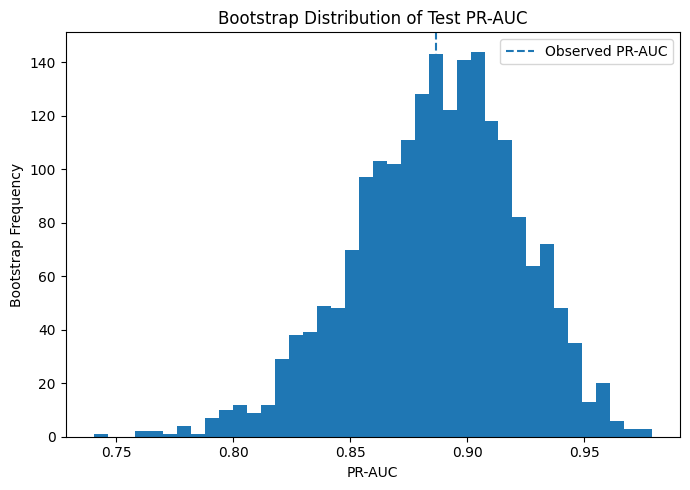

In [172]:
# Step 24D — Optional bootstrap distribution plots
# These are useful for supplementary material.

# For PR-AUC:

plt.figure(figsize=(7, 5))

plt.hist(
    bootstrap_results["PR_AUC"],
    bins=40
)

plt.axvline(
    xgb_test_results["PR_AUC"],
    linestyle="--",
    label="Observed PR-AUC"
)

plt.xlabel("PR-AUC")
plt.ylabel("Bootstrap Frequency")
plt.title("Bootstrap Distribution of Test PR-AUC")
plt.legend()

plt.tight_layout()

plt.savefig(
    FIGURES_DIR /
    "bootstrap_pr_auc_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

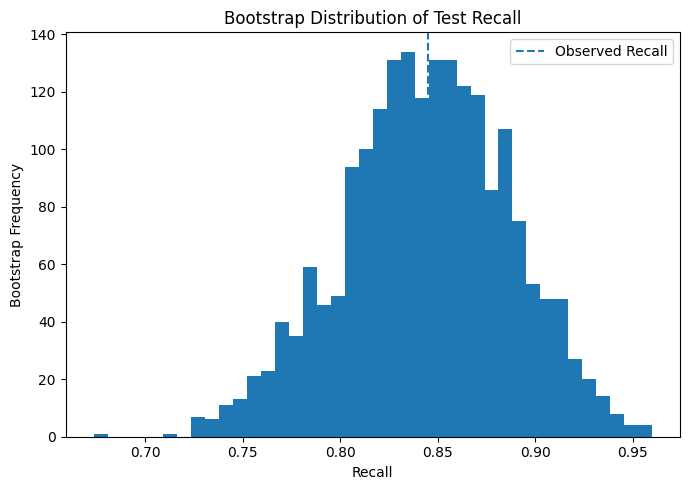

In [173]:
# And for recall:

plt.figure(figsize=(7, 5))

plt.hist(
    bootstrap_results["Recall"],
    bins=40
)

plt.axvline(
    xgb_test_results["Recall"],
    linestyle="--",
    label="Observed Recall"
)

plt.xlabel("Recall")
plt.ylabel("Bootstrap Frequency")
plt.title("Bootstrap Distribution of Test Recall")
plt.legend()

plt.tight_layout()

plt.savefig(
    FIGURES_DIR /
    "bootstrap_recall_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [174]:
# Step 25 — Save final model, configuration, and summary

import joblib

# Save final selected model
joblib.dump(
    primary_model,
    MODELS_DIR / "final_xgboost_model.pkl"
)

# Save final research configuration
final_configuration = {
    "Primary_Model": "XGBoost",
    "Model_Variant": "Original",
    "Decision_Threshold": float(best_threshold_xgb),
    "Primary_Conformal_Alpha": 0.10,
    "Marginal_Conformal_Quantile": float(q_marginal),
    "Random_State": RANDOM_STATE
}

joblib.dump(
    final_configuration,
    MODELS_DIR / "final_research_configuration.pkl"
)

print("Final model and configuration saved.")

Final model and configuration saved.


In [175]:
# Step 26 — Save final research summary table

final_research_summary = pd.DataFrame({
    "Metric": [
        "Test Accuracy",
        "Test Precision",
        "Test Recall",
        "Test F1",
        "Test ROC-AUC",
        "Test PR-AUC",
        "True Negatives",
        "False Positives",
        "False Negatives",
        "True Positives",
        "Conformal Target Coverage (alpha=0.10)",
        "Conformal Overall Coverage",
        "Conformal Normal Coverage",
        "Conformal Fraud Coverage",
        "Conformal Human Review Rate",
        "Conformal Confident Accuracy",
        "Confident Fraud Precision"
    ],
    "Value": [
        xgb_test_results["Accuracy"],
        xgb_test_results["Precision"],
        xgb_test_results["Recall"],
        xgb_test_results["F1"],
        xgb_test_results["ROC_AUC"],
        xgb_test_results["PR_AUC"],
        42483,
        6,
        11,
        60,
        0.90,
        0.902984022556391,
        0.9032220104026925,
        0.7605633802816901,
        0.096921992481203,
        0.9998959281904514,
        0.9818181818181818
    ]
})

print(final_research_summary)

final_research_summary.to_csv(
    RESULTS_DIR / "final_research_summary.csv",
    index=False
)

                                    Metric         Value
0                            Test Accuracy      0.999601
1                           Test Precision      0.909091
2                              Test Recall      0.845070
3                                  Test F1      0.875912
4                             Test ROC-AUC      0.984725
5                              Test PR-AUC      0.886794
6                           True Negatives  42483.000000
7                          False Positives      6.000000
8                          False Negatives     11.000000
9                           True Positives     60.000000
10  Conformal Target Coverage (alpha=0.10)      0.900000
11              Conformal Overall Coverage      0.902984
12               Conformal Normal Coverage      0.903222
13                Conformal Fraud Coverage      0.760563
14             Conformal Human Review Rate      0.096922
15            Conformal Confident Accuracy      0.999896
16               Confident Frau

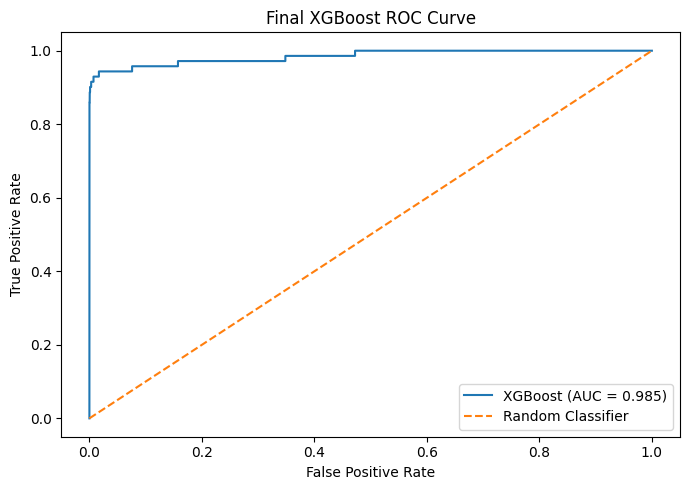

In [176]:
# Step 27 — Final ROC curve on test set

from sklearn.metrics import roc_curve, auc

fpr, tpr, _ = roc_curve(
    y_test,
    xgb_test_prob
)

roc_auc_value = auc(fpr, tpr)

plt.figure(figsize=(7, 5))

plt.plot(
    fpr,
    tpr,
    label=f"XGBoost (AUC = {roc_auc_value:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Final XGBoost ROC Curve")
plt.legend()

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "xgboost_final_test_roc_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

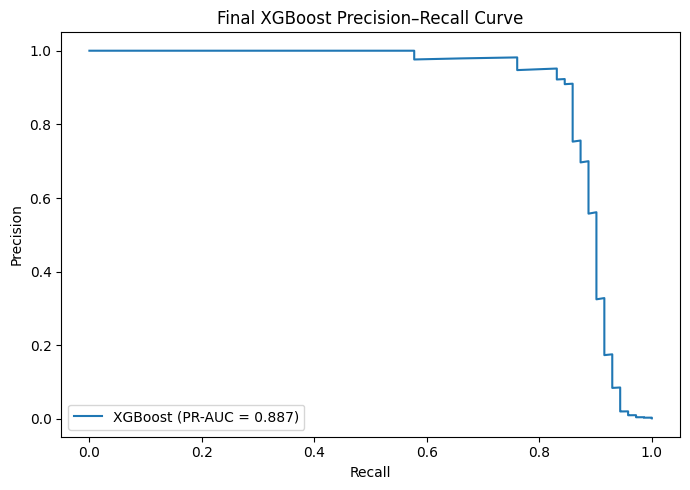

In [177]:
#  Step 28 — Final Precision–Recall curve

from sklearn.metrics import precision_recall_curve

precision_curve, recall_curve, _ = precision_recall_curve(
    y_test,
    xgb_test_prob
)

plt.figure(figsize=(7, 5))

plt.plot(
    recall_curve,
    precision_curve,
    label=f"XGBoost (PR-AUC = {xgb_test_results['PR_AUC']:.3f})"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Final XGBoost Precision–Recall Curve")
plt.legend()

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "xgboost_final_test_precision_recall_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [178]:
# Step 29 — Save bootstrap confidence intervals
# You already generated them, so just make sure they are saved:

bootstrap_ci_df.to_csv(
    RESULTS_DIR / "xgboost_final_test_bootstrap_confidence_intervals.csv",
    index=False
)

print("Bootstrap confidence intervals saved.")

Bootstrap confidence intervals saved.


In [179]:
# Step 30 — Save final conformal results

marginal_results_df.to_csv(
    RESULTS_DIR / "marginal_conformal_alpha_comparison.csv",
    index=False
)

print("Conformal sensitivity results saved.")

Conformal sensitivity results saved.


In [180]:
# Step 31 — Save final human-review decisions
#                 For α = 0.10:


final_human_review_df = pd.DataFrame({
    "True_Label": y_test_array,
    "Fraud_Probability": test_prob_fraud,
    "Prediction_Set": [
        str(s) for s in primary_sets
    ],
    "Decision": primary_decisions
})

final_human_review_df.to_csv(
    RESULTS_DIR / "final_human_review_decisions.csv",
    index=False
)

print("Final human-review decisions saved.")

Final human-review decisions saved.


In [181]:
# Step 32 — Final project file check

print("\nMODELS:")
for file in sorted(MODELS_DIR.iterdir()):
    print("-", file.name)

print("\nRESULTS:")
for file in sorted(RESULTS_DIR.iterdir()):
    print("-", file.name)

print("\nFIGURES:")
for file in sorted(FIGURES_DIR.iterdir()):
    print("-", file.name)


MODELS:
- final_research_configuration.pkl
- final_xgboost_model.pkl
- logistic_model.pkl
- model_thresholds.pkl
- primary_model_info.pkl
- random_forest_original.pkl
- random_forest_tuned.pkl
- xgboost_original.pkl

RESULTS:
- amount_summary_by_class.csv
- data_split_summary.csv
- final_human_review_decisions.csv
- final_research_summary.csv
- final_validation_model_comparison.csv
- marginal_conformal_alpha_comparison.csv
- random_forest_before_after.csv
- shap_global_feature_importance.csv
- shap_local_fraud_explanation.csv
- train_validation_overfitting_check.csv
- validation_model_comparison.csv
- xgboost_calibration_summary.csv
- xgboost_error_probability_summary.csv
- xgboost_false_negatives.csv
- xgboost_false_positives.csv
- xgboost_final_test_bootstrap_confidence_intervals.csv
- xgboost_final_test_results.csv

FIGURES:
- amount_distribution_by_class.png
- bootstrap_pr_auc_distribution.png
- bootstrap_recall_distribution.png
- class_distribution.png
- conformal_coverage_sensit

In [1]:
from pathlib import Path

PROJECT_DIR = Path.home() / "Pictures" / "Research Work"

folders = [
    "app",
    "src",
    "assets",
    "notebooks"
]

for folder in folders:
    (PROJECT_DIR / folder).mkdir(exist_ok=True)

print("Folders created successfully.")

for item in sorted(PROJECT_DIR.iterdir()):
    print(item.name)

Folders created successfully.
app
assets
creditcard.csv
creditcard_clean.csv
data_splits.pkl
figures
models
notebooks
Research.pdf
results
src
trustworthy_fraud_detection.ipynb


In [2]:
from pathlib import Path

PROJECT_DIR = Path.home() / "Pictures" / "Research Work"

for folder_name in ["models", "results", "figures"]:
    folder_path = PROJECT_DIR / folder_name

    print(f"\n{folder_name.upper()}")
    print("-" * 50)

    for item in sorted(folder_path.iterdir()):
        print(item.name)


MODELS
--------------------------------------------------
final_research_configuration.pkl
final_xgboost_model.pkl
logistic_model.pkl
model_thresholds.pkl
primary_model_info.pkl
random_forest_original.pkl
random_forest_tuned.pkl
xgboost_original.pkl

RESULTS
--------------------------------------------------
amount_summary_by_class.csv
data_split_summary.csv
final_human_review_decisions.csv
final_research_summary.csv
final_validation_model_comparison.csv
marginal_conformal_alpha_comparison.csv
random_forest_before_after.csv
shap_global_feature_importance.csv
shap_local_fraud_explanation.csv
train_validation_overfitting_check.csv
validation_model_comparison.csv
xgboost_calibration_summary.csv
xgboost_error_probability_summary.csv
xgboost_false_negatives.csv
xgboost_false_positives.csv
xgboost_final_test_bootstrap_confidence_intervals.csv
xgboost_final_test_results.csv

FIGURES
--------------------------------------------------
amount_distribution_by_class.png
bootstrap_pr_auc_distribut